# Predictive Analytics Project, Winter Term 2025/26

**Group members**:

- Dahyun Jung 7443700

- Bermet Stalbek 7444357

- Shalom Cornells 7443777

- Ammar Haider 7447213

In [397]:
# import packages here:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

## Day 1

In [398]:
df=pd.read_csv("Rides_daily.csv")

overview = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(),
})

overview["min"] = df.min(numeric_only=True)
overview["max"] = df.max(numeric_only=True)

overview

,dtype,missing_values,unique_values,min,max
ride_start_time,object,0,22487,NaN,NaN
ride_count,int64,0,429,1.0,492.00
ride_date,object,0,973,NaN,NaN
location_name,object,0,1,NaN,NaN
temperature_max,float64,0,266,-5.8,36.10
temperature_min,float64,0,242,-12.0,26.80
temperature_avg,float64,0,321,-8.7,30.70
feels_like_max,float64,0,339,-11.5,41.20
feels_like_min,float64,0,304,-20.3,29.60
feels_like_avg,float64,0,363,-14.9,34.70


## (a) Overview and description
The table above summarizes key information about each variable in the dataset, including data type, number of missing values, number of unique values, and (for numeric variables) minimum and maximum observed values.

Below is a one-sentence description of each variable based on the overview table.

Description of each variable

Ride Variables
- `ride_start_time` (object): the timestamp of when each ride count starts; 22,487 unique times, no missing values.
- `ride_count` (int64): the number of rides starting within each hour; ranges from 1 to 492, no missing values.
- `ride_date` (object): the date of each observation (973 unique days), no missing values.
- `location_name` (object): always the same value (1 unique); dataset corresponds to one Citi Bike station.

Temperature Variables
- `temperature_max/min/avg` (float64): daily temperature statistics; values range from -12°C to 36.1°C, no missing values.
- `feels_like_max/min/avg` (float64): perceived temperature with range of -20°C to 41°C, no missing values.
- `dew_point` (float64): dew point temperature from -18.7°C to 23.4°C, no missing values.
- `humidity_percent` (float64): hourly humidity level in percentage(24.3% to 94.5%), no missing values.

Precipitation & Weather Variables
- `precipitation_amount` (float64): rainfall accumulation in mm(0-71.66), no missing values.
- `precipitation_probability` (int64): probability of precipitation (0 or 100), no missing values.
- `precipitation_coverage` (float64): the percent of area affected (0-100%), no missing values.
- `precipitation_type` (object): type of precipitation (rain/snow). Hihgly missing since most hours have no precipitation.
- `snowfall`/ `snow_depth` (float64): snow accumulation variables; generally 0, with max value of 157.5mm (snowfall) and 183.8mm (snow_depth), no missing values.

Wind Variables
- `wind_gust` (float64): wind gust speed in mph; missing for 1,818 rows.
- `wind_speed` (float64): sustained wind speed (9.0 to 50.3mph), no missing values.
- `wind_direction` (float64): wind direction degrees (31.6° to 327.8°), no missing values.

Atmospheric & Solar Variables
- `sea_level_pressure` (float64): atmospheric pressure (989.9 to 1038.7 hPa), no missing values.
- `cloud_coverage` (float64): cloud cover percentage (0.1% to 100%), no missing values.
- `visibility_distance`(float64): visibility in miles (2.2 to 16 miles), no missing values.
- `solar_radiation` (float64): solar radiation in W/m² (7.7 to 354.8), no missing values.
- `solar_energy` (float64): solar energy (kWh/m²); ranges 0.7 to 30.8, no missing values.
- `uv_index` (int64): UV index (0-10), no missing values.
- `severe_weather_risk` (float64): scale from 10 to 100 indicating risk of severe weather; 16,912 missing values becasue severe events are rare.

Sun & Moon Variables
- `sunrise_time`/ `sunset_time` (object): times of sunrsie and sunset (vary); no missing values.
- `moon_phase` (float64): illumination percentage (0 to 1), no missing values.

Weather Description Variables
- `weather_conditions`/ `weather_description`/ `weather_icon` (object): textual categorial weather descriptions and icons; no missing values.
- `weather_stations` (object): station identifies; 8 unique values with no missing values.


The dataset contains a mix of ride activity variables, temperature/precipitation measures, wind and atmospheric conditions, and sun/moon/weather descriptors. Most weather-related variables have no missing values, while precipitation-related and severe-weather variables have many missing entries due to their rarity (which mostly is expected and within normal range). 

## (b) How many days worth of data we have?

In [399]:
#Count how many days of data we have

#convert ride_date column to a datatime format
df['ride_date'] = pd.to_datetime(df['ride_date'])

#count the number of unique dates
num_days = df['ride_date'].nunique()
num_days

973

In [400]:
#Count how many total obs we have
num_obs = len(df)
num_obs

22487

In [401]:
#How many hours per day are included
hours_per_day = num_obs/ num_days
hours_per_day

23.110996916752313


The data set has 973 days of data and 22,487 hourly observations. Hence, on average, there are about 23.1 hourly observations per day. Because we have 24 hours fixed in a day, we must have some missing hours.

## (c) Do we have the same number of observations for each hour and day?

In [402]:
#Count rows per day
counts_per_day = df.groupby("ride_date").size()
counts_per_day.describe()

#Extract hour from ride_start_time:
df['hour'] = pd.to_datetime(df['ride_start_time']).dt.hour
counts_per_hour = df.groupby("hour").size()
counts_per_hour

hour
0     938
1     880
2     766
3     712
4     844
5     931
6     967
7     970
8     968
9     970
10    967
11    969
12    970
13    969
14    970
15    970
16    970
17    971
18    971
19    967
20    968
21    966
22    962
23    951
dtype: int64

We do not have the same number of observations for each hour and day. 
When counting observations per day, we find an average of 23.1 hourly entries per day, instead of the expected 24 hours for a complete day. This shows that some hours are missing. 

The dataset covers 973 days, so if every day had complete data, each hour would appear exactly  973 rows per hour. But the counts range from 712 to 970, which shows large difference. This means some hours are missing more often than others. Most missing hours occur early morning (2-5AM).

Implication:
If we have hours with zero rides missing from the dataset, then the data will only contain hours where at least one ride happened, while excluding zero-demand hours. This creates bias because only good (higher demand) hours are icluded. As a result: 
- the average rides per hour will be too high, because hours with zero rides are never included.
- the data will appear to show continuous demand even when actual demand falls to zero at times.
- modeling would be based on biased data and will overestimate the true demand data.

So, missing zero-ride hours disrupts the true ride pattern and causes overestimated average of ridership.

## (d) Which variables have the strongeset correlation with the number of rides?

In [403]:
#Make sure ride_count is numeric
df['ride_count'] = pd.to_numeric(df['ride_count'], errors = 'coerce')
#compute correlations for numeric variables only
corr = df.corr(numeric_only=True)['ride_count'].sort_values(ascending=False)
corr

ride_count                   1.000000
temperature_avg              0.390432
feels_like_avg               0.385408
temperature_max              0.384597
temperature_min              0.383181
feels_like_min               0.382374
feels_like_max               0.373497
hour                         0.341150
dew_point                    0.329990
uv_index                     0.288487
solar_energy                 0.266795
solar_radiation              0.266774
severe_weather_risk          0.203527
visibility_distance          0.117596
wind_gust                    0.047562
precipitation_probability    0.002518
moon_phase                  -0.001257
wind_direction              -0.002655
humidity_percent            -0.022396
sea_level_pressure          -0.028837
snowfall                    -0.033874
precipitation_amount        -0.041691
cloud_coverage              -0.044461
snow_depth                  -0.078687
wind_speed                  -0.096811
precipitation_coverage      -0.126296
Name: ride_c

In [404]:
#top 10 strongest correlations

corr.head(10)

ride_count         1.000000
temperature_avg    0.390432
feels_like_avg     0.385408
temperature_max    0.384597
temperature_min    0.383181
feels_like_min     0.382374
feels_like_max     0.373497
hour               0.341150
dew_point          0.329990
uv_index           0.288487
Name: ride_count, dtype: float64

Using the top 10 strongest correlations, we find that temperature-related variables have the highest positive correlations with the number of rides. Here we pick 3 strongest:
1. `temperature_avg` (correlation ~0.39)
- `Temperature_avg` has the strongest positive correlation with ride_count. As the average temperature increases, the number of rides increases a lot. This makes sense becasue biking is more appealing in comfortable weather; cold temperatures discourage riding while warm temperatures encourage. This suggests that temperature is a key driver of overall demand.
2. `feels_like_avg` (correlation ~0.385)
- The perceived average temperature also strongly predicts ride. The perceived temperature can vary due to wind or humidity causing people to make it feel colder or hotter despite moderate temperature. A higher feels-like average is associated with more riders, meaning perceived comfrot is important like actual temperature.
3. `temperature_max` (correlation ~0.385)
- The maximum temperature also has a strong positive correlation with ride_count. Warmer temperature increase the likelihood of people biking. This indicates that the peak warmth is also significant influence on ridership.

Overall, we see that warmer and more comfortable weather conditions tend to cause higher bike ridership.

## (e) Four meaningful diagrams

### 1. Histogram

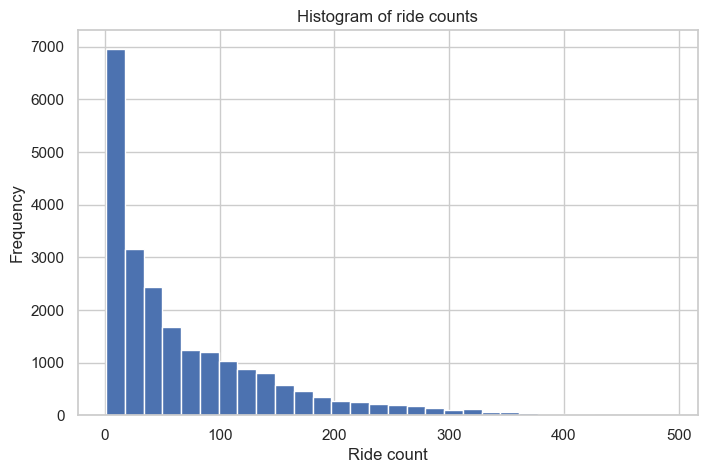

In [405]:
# Histogram  of ride counts
plt.figure(figsize=(8,5))
plt.hist(df['ride_count'], bins=30)
plt.xlabel("Ride count")
plt.ylabel("Frequency")
plt.title("Histogram of ride counts")
plt.show()

The histogram shows the distribution of hourly ride counts across the dataset.
Most hours have relatively low ride counts. This indicates that low-demand hours are very common. The distribution is right-skewed, with fewer hours having higher ride counts. A smaller number of hours reach about 200 rides (and continues to decline).

Overall, the histogram reveals that while the system occasionally experiences high demand, the majority of hours have moderate level of ridership.

### 2. Bar chart - 1

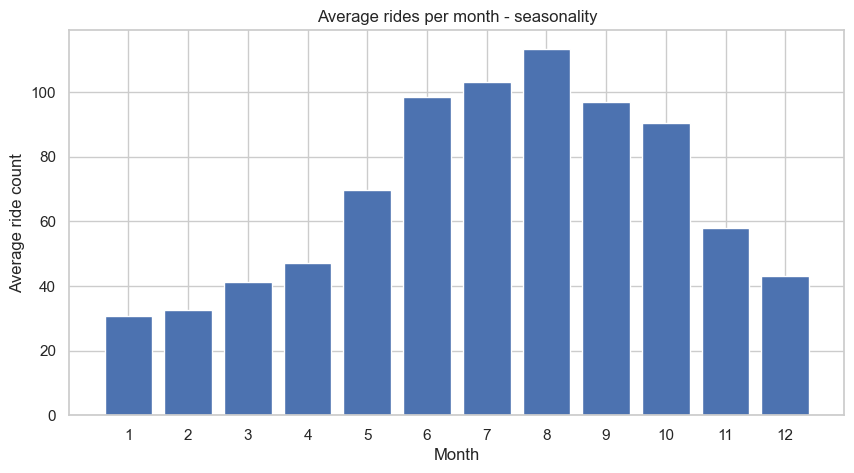

In [406]:
#Bar chart - Average rides per month (seasonality)

#convert date column
df['ride_date'] = pd.to_datetime(df['ride_date'])
#extract month
df['month'] = df['ride_date'].dt.month
#compute average rides per month
monthly_avg = df.groupby('month')['ride_count'].mean()


plt.figure(figsize=(10,5))
plt.bar(monthly_avg.index, monthly_avg.values)
plt.xlabel("Month")
plt.ylabel("Average ride count")
plt.title("Average rides per month - seasonality")
plt.xticks(range(1,13))
plt.show()

The chart shows clear seasonality in ridership. Winter months (e.g.December to February) have the fewest ride counts, while summer months (June to August) have the highest average ride counts. This corresponds to that people cycle far less in winter, likely due to cold temperatures, snow, and shorter daylight.

### 3. Bar Chart - 2

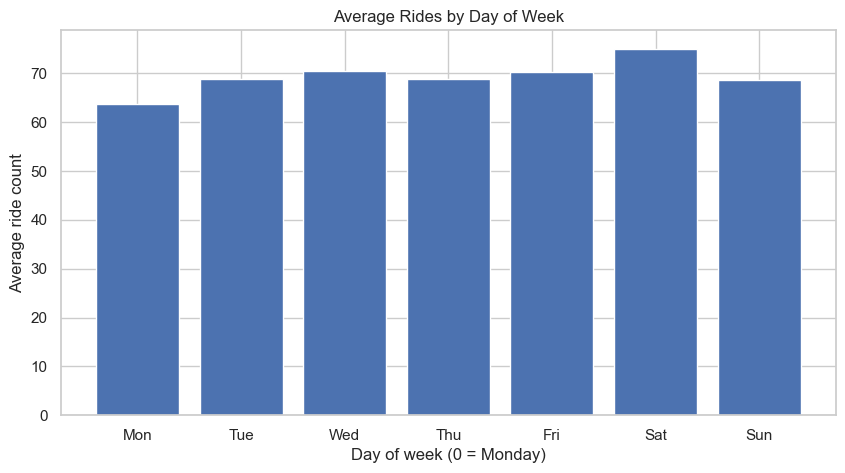

In [407]:
# Bar chart - Average rides per day of week

#Extract weekday (0 as Monday, 1 as Tuesday, ..., 6 as Sunday)
df['weekday'] = df['ride_date'].dt.dayofweek

#compute average rides per weekday
weekday_avg = df.groupby('weekday')['ride_count'].mean()

plt.figure(figsize=(10,5))
plt.bar(weekday_avg.index, weekday_avg.values)
plt.xlabel("Day of week (0 = Monday)")
plt.ylabel("Average ride count")
plt.title ("Average Rides by Day of Week")
plt.xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.show()

The bar chart shows how average ridership varies across the days of the week. 
- Saturday shows the highest number of rides, suggesting many riders with possible weekend activities.
- Sunday also has high usage, though lower than Saturday.
- Weekdays show moderate ridership, likely due to commuting patterns.
- Monday has the lowest average ride count.

The data suggests that ridership is driven more by the usage on the weekends than by commuting during the weekdays. The high Saturday and Sunday counts suggest strong demand for usage, while the relatively lower Monday usage suggests that riders may rely more on other forms of commuting at the start of the week rather than bikes. 

### 4. Scatter plot

Temperature is selected as the variable to compare with ride counts because it is one of the strongest predictors of cycling and intuitively makes sense. 
- Warmer temperatures generally create more comfortable conditions for riding, while cold temperatures discourage.
- This relationship also appeared strongly in the correlation analysis, where temperature-related variables showed some of the highest correlation with ride_count.


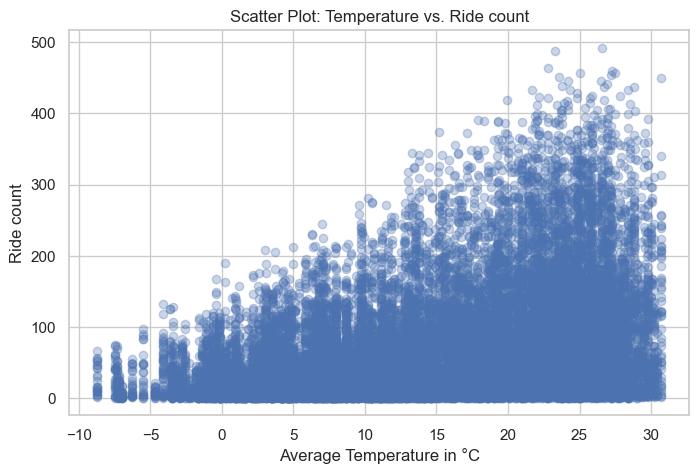

In [408]:
plt.figure(figsize=(8,5))

#Scatter plot
plt.scatter(df['temperature_avg'], df['ride_count'], alpha=0.3)
plt.xlabel("Average Temperature in °C")
plt.ylabel("Ride count")
plt.title("Scatter Plot: Temperature vs. Ride count")

plt.show()

This scatter plot shows the relationship between the average temperature and the number of bike rides. There is a clear upward trend: as temperature rises, the number of rides also rise. On cold days with temperature below 0°C, ride counts is relatively low, while warmer temperatures between 15 to 30°C are related with higher and more variable ride counts.

This trend makes intuitive sense as warmer weather creates more comfortable riding conditions, while colder temperature discourage outdoor activity such as biking. Although we should consider natural variability in ride counts at each level of temperature, the overall trend shows positive relationship, hence we conclude that temperature is an importnat factor for ridership demand.

## (f) Diagram to show "over the time horizon"

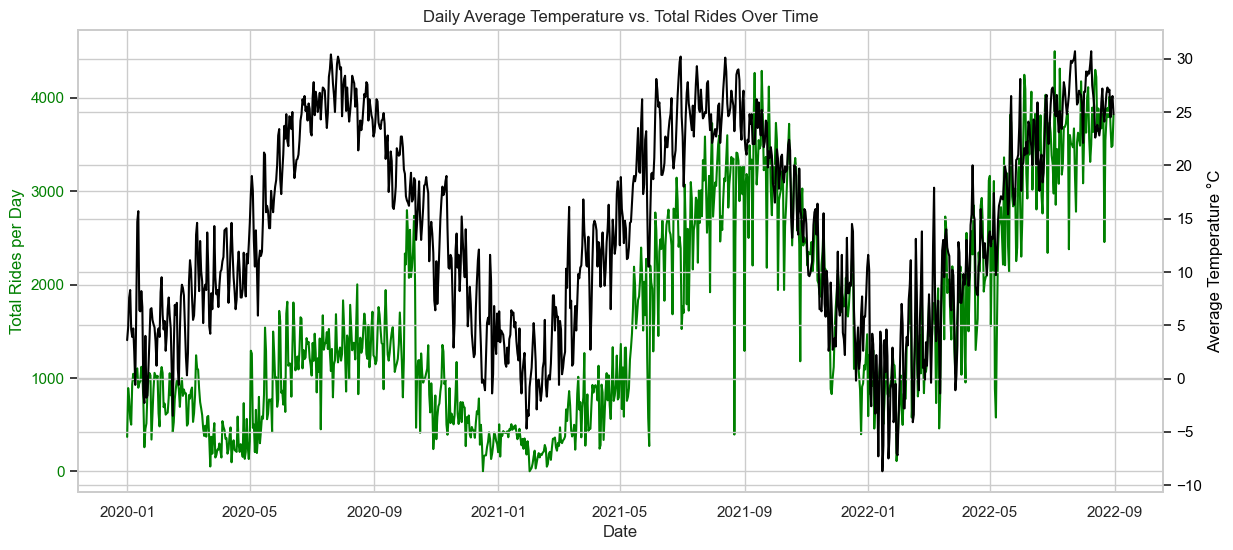

In [409]:
#compute average temperature per day
temp_per_day = df.groupby('ride_date')['temperature_avg'].mean()

#compute total number of rides per day
rides_per_day = df.groupby('ride_date')['ride_count'].sum()

#first axis(left-hand side) for total rides
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(rides_per_day.index, rides_per_day.values,
         color='green', label='Total Rides per Day')
ax1.set_xlabel("Date")
ax1.set_ylabel("Total Rides per Day", color='green')
ax1.tick_params(axis='y', labelcolor='green')

#second axis(right-hand side) for temperature
ax2 = ax1.twinx()
ax2.plot(temp_per_day.index, temp_per_day.values,
         color='black', label='Average Temperature °C')
ax2.set_ylabel("Average Temperature °C", color='black')
ax2.tick_params(axis='y', labelcolor='black')

#organizing the plot
plt.title("Daily Average Temperature vs. Total Rides Over Time")
plt.grid(True)
plt.show()

The diagram plots two time-series on the same axis:
- Average temperature per day (on the right hand side)
- Total number of rides per day (on the left hand side)

We observe the following:
- During the warmer months, temperature increase and the number of daily rides also increase. We observe high ridership, often exceeding 3,000 rides per day; even higher in later time.
- During the colder months, temperature decrease and the number of daily rides also decrease. Sometimes, it falls below 500 rides per day when temperature is near 0 to -5°C.

The two curves move closely together over time: when temperature rises, ridership rises; when temperature drops, ridership drops. This suggests that temperature is a significant driver of overall ridership. 

While day-to-day fluctuations are observed, the overeall trend indicates strong positive relationship between temeprature and ridership across the entire time, which is consistent with finding from correlation analysis from (d) and multiple diagrams from (e).

Aside from the seasonal pattern, the chart also shows an increase in overall ridership from 2020 to 2022. 
- In 2020, peak daily ridership rarely exceeded 2,500 to 3,000 range.
- In 2021, peak values exceeded 4,000 rides per day but also we observe that overall ridership rose.
- In 2022, several peak days approached 4,500+ rides.

This upward trend suggests that the CitiBike system saw growing usage over time. Reasons behind this trend may vary:
- More riders in general population
- Expansion in service
- Increased preferences for bikes compared to other commuting forms.

Therefore, we gain two insights:
1. Temperature and ridership move together, suggesting that weather conditions are an importnat determinant and driver of bike usage.
2. Ridership has grown over the years, suggesting underlying factors may exist that influence demand for ridership.

### Fixing the issue

In (c), we found that the dataset contains, on average, 23.1 hourly observations per day instead of the expected 24 hours. We discussed that it meant that there are missing hourly observations. Ignoring these missing hours would cause the analysis to be disorted especially for nighttime hours. It makes sense that at late night, no rides occur (e.g. sleeping). So, having these values in the analysis would cause average ridership to be overstated and we would have following regression models to overpredict the ridership. So, we add the missing hours and set them as zero count to get the full dataset. This allows to get full hourly time series with each day of 24 hours that represent better reflection of ridership.

In the following cell, we fix the issue. Because (a)-(f) in Day 1 was purely exploratory and descriptive analysis, we do not re-run everything again here. We only provide histogram of average hourly count for comparison reason to original dataset. In following analysis (Day 2 and onwards), we use corrected dataset.

In [410]:

#convert the column to datetime format
df['datetime'] = pd.to_datetime(df['ride_start_time'])

#create hourly timestamps
full_index = pd.date_range(
    start=df['datetime'].min().floor('h'),
    end=df['datetime'].max().ceil('h'),
    freq='h'
)

#reindex for missing hours (we created df_fixed=df.copy())
df_fixed = (
    df.set_index('datetime')
      .reindex(full_index)
      .rename_axis('datetime')
      .reset_index()
)

#change missing counts with zero!
df_fixed['ride_count'] = df_fixed['ride_count'].fillna(0)

#recreate time-based columns in case of groupbys and plots
df_fixed['ride_date'] = df_fixed['datetime'].dt.date
df_fixed['hour'] = df_fixed['datetime'].dt.hour

#checking
print("Days:", df_fixed['ride_date'].nunique())
print("Rows:", len(df_fixed))
print("Hours per day:", len(df_fixed) / df_fixed['ride_date'].nunique())

Days: 974
Rows: 23376
Hours per day: 24.0


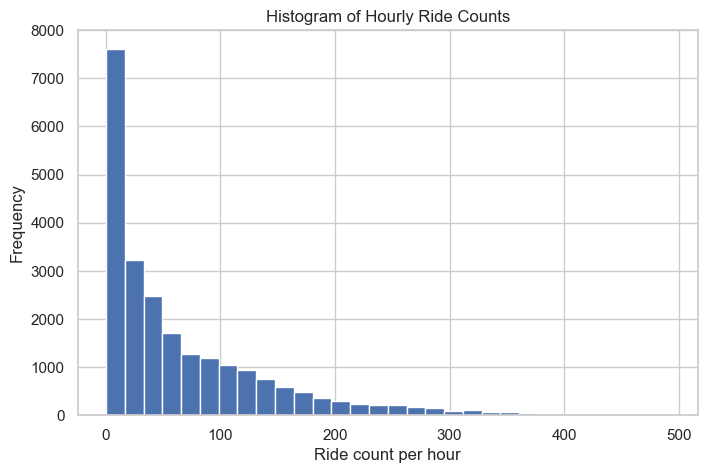

In [411]:
#histogram of hourly ride counts with corrected data for comparison!
plt.figure(figsize=(8,5))
plt.hist(df_fixed['ride_count'], bins=30)
plt.xlabel("Ride count per hour")
plt.ylabel("Frequency")
plt.title("Histogram of Hourly Ride Counts")
plt.show()

By comparing histogram of hourly ride count, we see increased counts for 0 compared to original histogram in (e). 

## Day 2

## (a) Regression 

In [412]:
#convert df again so we use df_fixed as df onwards!
df=df_fixed.copy()
df['datetime']=pd.to_datetime(df['datetime'])

#with converted items into datetime, extract hour, month, weekday, and weekend
#ridership varies by time frames, so we create time-related variables and have dummies corresponding to each.
df['hour']=df['datetime'].dt.hour #0-23, to have meaningful interpretation we keep dummies.
df['month']=df['datetime'].dt.month #1-12, to have meaningful interpretation we keep dummies.
df['weekday']=df['datetime'].dt.dayofweek #0 = Mon, ..., 6 = Sun

#We create "weekend" to avoid 7 dummies for weekday
df['weekend']=df['weekday'].isin([5,6]).astype(int) #1 = Sat/Sun, 0 = otherwise

#when weather is missing, we take previous/most recent value
weather_cols = ['temperature_avg', 'humidity_percent', 'precipitation_amount']
df[weather_cols] = df.groupby(df['datetime'].dt.date)[weather_cols].ffill()

### Model 1

In [413]:
# Model 1: Weather + Month + Weekend
model1=smf.ols(
    formula=(
        'ride_count ~ temperature_avg + humidity_percent + precipitation_amount'
        '+ C(month) + weekend'
    ),
    data=df
).fit()

print("===== Model 1: Weather + Month + Weekend =====")
print(model1.summary())

===== Model 1: Weather + Month + Weekend =====
                            OLS Regression Results                            
Dep. Variable:             ride_count   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     357.8
Date:                Fri, 19 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:20:26   Log-Likelihood:            -1.3137e+05
No. Observations:               23246   AIC:                         2.628e+05
Df Residuals:                   23230   BIC:                         2.629e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

Model 1 is formulated using weather and seasonal variables (month and weekend).
The goal of this model is to understand how weather conditions and seasonal patterns influence hourly ridership.

This model includes:
- `temperature_avg`: temperature had one of the strongest positive correlations with ride counts. Ridership is highly weather-sensitive.
- `humidity_percent`: humidity affects comfort and may reduce ridership if high.
- `precipitation_amount`: rain or snow strongly reduces likelihood of cycling.
- `C(month)`: captures seasonal changes (winter vs. summer) using months.
- `weekend`: weekends often show different activity levels than weekdays, and our earlier plots confirmed higher usage.

Taken together, this makes model 1 a realistic model of factors influencing ridership demand.

### Consideration for Model 1
The project includes the instruction: "Take a look at the model predictions you get for the number of hourly rides in December at midnight. Do you see any issues?".

This hint signals a modeling problem:
- A weather-only model would predict the same ridership at noon and at midnight, as long as the weather is the same.
- But in reality, ridership at midnight would be close to zero.
- Similarly, December naturally has lower cycling activity (as it is colder).

Therefore, to reduce unrealistic predictions (e.g. predicting many rides at midnight in December because temperature happens to be moderate), Model 1 incorporates seasonality. This is why C(month) and weekend were added to Model 1.

These variables allow the model to:
- Recognize that December is fundamentally different from July,
- Account for seasonal behavior that weather alone cannot explain,
- Reflect weekly patterns,
- Produce more reasonable predictions in low-activity periods like winter months.

### Interpretation
Key insights:
1. Temperature strongly increases ridership: temperature_avg coefficient ≈ +2.81
   - For each 1°C increase in temperature, the model predicts about 2.8 more rides per hour, holding others constant.
   - This confirms that warmer weather encourages cycling, consistent with earlier correlation results and diagrams.
2. Humidity reduces ridership: humidity_percent coefficient ≈ –0.68
   - A 1 percent increase in humidity decreases ridership by about 0.7 rides per hour.
   - High humidity often means discomfort or forecasting bad weather conditions.
3. Precipitation strongly reduces ridership: precipitation_amount coefficient ≈ –0.46
   - Every additional mm of precipitation leads to 0.46 fewer rides per hour.
   - This confirms the intuitive insight that people avoid riding bikes when it rains or snows.
4. Weekend ridership is higher: weekend coefficient ≈ +4.31
   - On weekends, ridership increases by about 4 additional rides per hour, after controlling for weather and season.
   - This means that model predicts more trips on weekends, aligning with usage patterns observed in earlier charts.
5. Seasonal patterns (months) matter:
   - Several months show statistically significant positive coefficients, while winter months show negative or smaller effects.
   - Summer months (June to September) have much higher hourly ridership, likely due to favorable weather conditions along with longer daytime. Winter months show reduced ridership, consistent with cold temperatures and snow.

Model 1 shows that weather variables (temperature, humidity, precipitation) are highly significant drivers of hourly ridership. Temperature increases ridership, while humidity and precipitation reduce it. The weekend dummy is also significant and suggests higher usage on weekends.

Several month dummies are statistically insignificant. This is because month and weather follow overlapping information about seasonality. Temperature, humidity, and precipitation already explain most of seasonal pattern in ridership. As a result, the month variables do not provide much additional explanatory power, creating multicollinearity between seasonal effects and weather effects. 

We find evidence of multicollinearity in output:
- Some month coefficients become insignificant, despite clear seasonal patterns in the data.
- The condition number in the model summary is very high.

As a result, months such as February, May, November, and December do not differ significantly from January (baseline). Multicollinearity reduces the statistical significance and interpretability of these coefficients. 

### Model 2

In [414]:
# Model 2: Hour-only model

model2=smf.ols(
    formula='ride_count ~ C(hour)',
    data=df
).fit()

print("===== Model 2: Hour-only Model =====")
print(model2.summary())

===== Model 2: Hour-only Model =====
                            OLS Regression Results                            
Dep. Variable:             ride_count   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     516.3
Date:                Fri, 19 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:20:26   Log-Likelihood:            -1.2972e+05
No. Observations:               23376   AIC:                         2.595e+05
Df Residuals:                   23352   BIC:                         2.597e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept

Model 2 is formulated using only time-of-day variables (hour of day), becasue our earlier analysis showed that hour is one of the strongest predictors of hourly ridership. 
- From the correlation analysis: hour-of-day explained more variation in ride_count than other weather variable.
- From the descriptive plots: the hourly distribution plots showed large differences between hours of the day.


The goal of this model is to understand how ridership changes within a single day, independent of weather or season.

This model includes `C(hour)`: a categorial (dummies) variable that creates 24 hour-specific effects. This allows the model to estimate a different average ridership level for every hour. Hours such as early morning or late afternoon often have higher cycling activity due to commuting, whereas late-night and early-morning hours typically show very low demand.

This model is useful because:
1. It captures the daily ridership cycle that weather variables alone cannot explain.
2. It avoids overlap with Model 1 to have a model to predict with different predictor.

Taken together, Model 2 provides interpretable picture of how ridership varies across the 24-hour day.

## Interpretation

Model 2 estimates how the average number of hourly rides differs across the 24 hours of the day. Because `C(hour)` is a categorial variable, the model uses one hour as the reference category. We take hour 0 as midnight. The intercept represents the predicted number of rides at midnight and each coefficient shows how much the predicted hourly rides differ from midnight.

Key insights:
1. Intercept: 20.64
   - At midnight(reference), the model predicts about 21 rides per hour on average, pooling all days and seasons.
2. Low nighttime ridership: Hours 1 to 5 all have negative or small positive coefficients, meaning they are significantly quieter than midnight.
3. Increase in early morning: Hours 6 to 8 show large positive increases, linked to commuting we assume.
4. 8AM peak - morning commute likely
5. 5-6PM peak - it has the largest coefficient.
6. Evening decline: after 7PM, coefficients begin decreasing
7. After the evening peak, predicted ridership gradually decreases as turning into the night.

This model captures the daily cycling cycle:
- Night: minimal usage
- Morning: sharp rise
- Afternoon: another strong peak
- Evening: gradual decline

Nearly all predictors are statistically significant and the coefficients quantify exactly how much each hour differs from the reference hour, giving a detailed profile.

## (b) Predict the number of rides of an average hour in July at noon

In [415]:
#Filter the data to July at noon:
july_noon = df[(df['month'] == 7) & (df['hour'] == 12)]

print("Number of July-noon observations:", len(july_noon))

Number of July-noon observations: 93


### Model 1

In [416]:
# Model 1
#compute mean of each variable to find average July-noon weather and chance of it being a weekend
mean_temp = july_noon['temperature_avg'].mean()
mean_humidity = july_noon['humidity_percent'].mean()
mean_precip = july_noon['precipitation_amount'].mean()
mean_weekend = july_noon['weekend'].mean()

#X1_new as "average July noon" hour
X1_new=pd.DataFrame({
    'temperature_avg': [mean_temp],
    'humidity_percent': [mean_humidity],
    'precipitation_amount': [mean_precip],
    'month': [7], #July
    'weekend': [mean_weekend]
})

#Prediction
pred_model1=model1.predict(X1_new)
print("Predicted rides (Model 1):", float(pred_model1.iloc[0]))

Predicted rides (Model 1): 102.93906810035702


### Model 2

In [417]:
# Model 2
#X2_new as "average July noon" hour
X2_new = pd.DataFrame({'hour':[12]}) # noon

#Prediction
pred_model2=model2.predict(X2_new)
print("Predicted rides (Model 2):", float(pred_model2.iloc[0]))

Predicted rides (Model 2): 88.60164271048521


### Interpretation

To compare the two regression models, we predict the expected number of rides for an average July noon hour. Model 1 includes weather and seasonal variables, while Model 2 includes only the hour-of-day dummies where the required input is the hour = 12 (noon).

Prediction results:

Model 1 ≈ 102.94 rides

Model 2 ≈ 88.60 rides

The models differ in their predictions:

Model 1 predicts a higher value. It includes weather variables and seasonal effects. July typically has:
- warm temperatures,
- low precipitation,
- higher ridership overall

These features in July increase the predicted ridership, which explains why Model 1 produces a higher estimate. It produces realistic values for a specific scenario becasue it incorporates the factors that strongly influence ridership. However, because Model 1 does not include hour-of-day effects, it would predict the same ridership at midnight if given the same conditions.

Model 2 predicts a lower value. It uses only the hour of day and does not know anything about the weather or month. Its prediction for noon is therefore an average noon across the entire dataset, which even includes:
- winter months with very low ridership
- rainy and snowy conditions

Hence, its noon prediction is lower than Model 1. 

Overall, Model 1 predicts substantially more rides at a July noon hour becasue it accounts for favorable weather and seasonal conditions that are typical of July. Model 2 gives a lower estimate because it averages noon ridership over all months and weather conditions. Therefore, the models differ meaningfully in their predictions.

## (c) Residuals

### Model 1

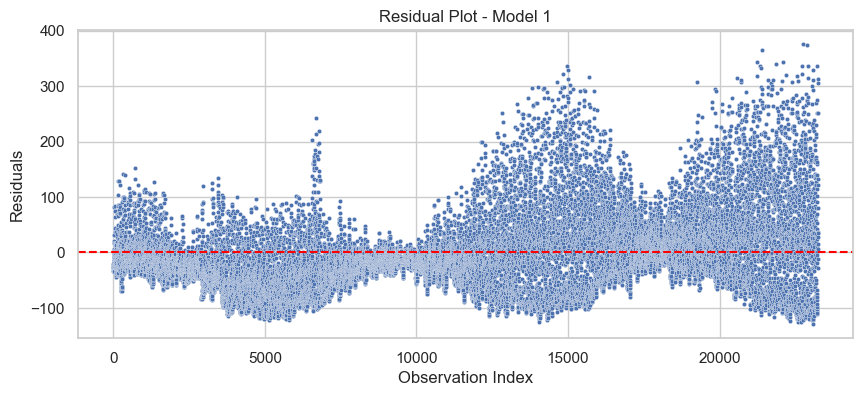

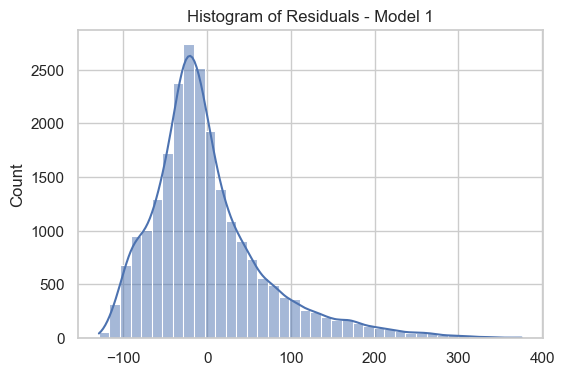

In [418]:
#exract residuals
resid1 = model1.resid

#residual scatter plot
plt.figure(figsize=(10,4))
sns.scatterplot(x=range(len(resid1)), y=resid1, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot - Model 1")
plt.xlabel("Observation Index") #time order of data
plt.ylabel("Residuals") #value of residuals
plt.show()

#Histogram of residuals to do distribution check
plt.figure(figsize=(6,4))
sns.histplot(resid1, bins=40, kde=True)
plt.title("Histogram of Residuals - Model 1")
plt.show()

### Interpretation - Model 1

1. Scatter plot: The residual plot for model 1 shows a structure:
   - The residuals form waves and long stretches of positive and negative values. This indicates autocorrelation, meaning time-related patterns are unexplained.
   - The spread of residuals changes over the index: this suggests heteroskedasticity, meaning the model's errors vary depending on the time period (e.g. summer peaks).
   - The model underpredicts ridership during peaks and overpredicts during low activity hours.

This happens because Model 1 does not include the hour-of-day variable. Without it, the model cannot capture the daily ridership cycle. 

2. Histogram: It shows right-skewed distribution:
   - There is a cluster of residuals around zero, but many large positive residuals pull the distribution to the right.
   - The long right tail violates the OLS assumption of normal distribution.

Due to right-skeweness, predictions in extreme conditions become unreliable. Also, confidence intervals and hypothesis tests are less trustworhty. 

To reduce autocorrelation, heteroskedasticity, and skewed errors, the model should include time-of-day information (e.g. hour dummies) or use a more flexible model that captures daily ridership cycles. Adding the hour variable would account for the strongest pattern in the data and reduce structured residuals.


### Model 2

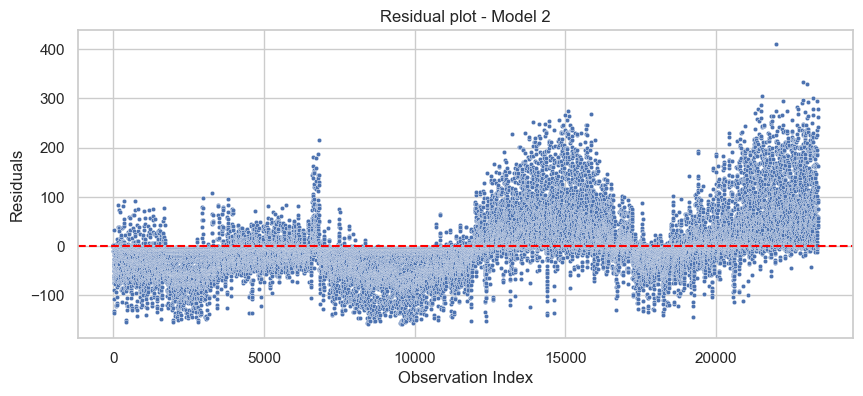

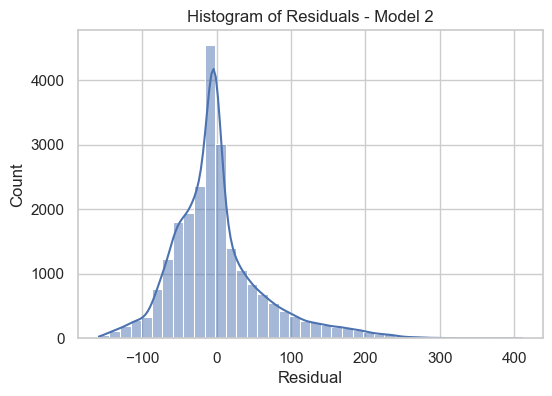

In [419]:
#extract residuals for model 2
resid2=model2.resid

#residual scatter plot
plt.figure(figsize=(10,4))
sns.scatterplot(x=range(len(resid2)), y=resid2, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual plot - Model 2")
plt.xlabel("Observation Index") # time order of data
plt.ylabel("Residuals") #value of residuals
plt.show()

#histogram of residuals to check distribution
plt.figure(figsize=(6,4))
sns.histplot(resid2, bins=40, kde=True)
plt.title("Histogram of Residuals - Model 2")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

### Interpretation - Model 2

1. Scatter plot: The residual plot shows structure:
   - Wave-like patterns across the entire index: the residuals rise and fall systematically, indicating autocorrelation - the model is missing importnat factors such as weather or season.
   - Residuals spread changes over time, meaning it suggests heteroskedasticity.
   - It underpredicts high-demand periods like summer afternoons, while overpredicts low-demand periods.

The model fails to capture seasonality and weather variation, leading to patterned and non-random residuals.

2. Histogram: right-skewed:
   - Many residuals cluster around zero, but long positive tails show large underpredictions during high-demand hours.
   - Negative residuals are smaller in magnitude, showing that the model usually overpredicts less severe cases than it underpredicts peak activity.

Residuals are not symmetric and not normal, making confidence intervals and hypothesis tests less reliable.


Model 2 uses only hour-of-day as predictors, ignoring temperature, precipitation, humidity, seasonal differences, etc. Because of this, the model estimates one average pattern for each hour across all seasons. This casues errors during summer peaks, winter lows, and patterns in residuals.

To fix these issues, the model should include additional predictors such as weather variables, weekend indicator, or montly seasonality. These predictors could reduce autocorrelation, heteroskedasticity, and give more realistic predictions.

## Further recommendation

Based on the residual analysis for both models, the main issues arise because each model omits importnat drivers of hourly ridership. 

Model 1 includes: temperature, humidity, precipitation, month, and weekend. But it misses hour, which is the strongest determinant of hourly ridership. 

Model 2 includes: hour-of-day. It ignores other variables which influence the magnitute of ridership.

Combining Model 1 and Model 2 would fix the issues of each model we interpreted above.

A combined model can capture the issues and resolve. We only provide example of the following model for suggestion: 

`ride_count` ~ `C(hour)` + `temperature_avg` + `humidity_percent` + `precipitation_amount` + `C(month)` + `weekend`

This allows the combined model to incorporate:
- Daily pattern by hour
- Seasonal pattern (month, weekend)
- Weather variation (temperature, rain, humidity)

Together, these are the core drivers of hourly ridership. 

Also, the problems would be solved:
- Autocorrelation would be reduced because the largest repeated pattern (hourly cycle) would be modeled well.
- Heteroskedasticity would be reduced because weather explains why variance is bigger in summer.
- Large positive residuals would shrink because including hour and weather fixes unpredicted peak hours.
- Skewness would decrease because with structure, residuals become more symmetric.

## Day 3

## (a) Classification Model

In [420]:
# Day 3 – Predictive Maintenance (Classification)

# Display settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")



In [421]:
#Adjust the path
full_data_path = "predictive_maintenance.csv"

#Read the file
df_full = pd.read_csv(full_data_path)

#Print to see how big the dataset is
print("Full dataset shape:", df_full.shape)
df_full.head()

# Check for missing values
missing_values = df_full.isnull().sum()

#Print Summary
print("=== INFO (full dataset) ===")
print(df_full.info())

print("\n=== Missing values per column ===")
print(df_full.isna().sum())
 

Full dataset shape: (10000, 11)
=== INFO (full dataset) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
 10  Monday                   10000 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 859.5+ KB
None

=== Missing values per column ===
UDI                       

### Interpretation: Dataset structure and missing values

The full predictive maintenance dataset contains **10,000 observations** and **11 columns**.
The columns include:

- Two identifiers: `UDI` and `Product ID`
- A categorical variable: `Type` (e.g. L, M, H)
- Several continuous sensor/process variables:
  - `Air temperature [K]`
  - `Process temperature [K]`
  - `Rotational speed [rpm]`
  - `Torque [Nm]`
  - `Tool wear [min]`
- Two dependent variables:
  - `Target` (binary: 1 = faulty part, 0 = non-faulty part)
  - `Failure Type` (categorical, e.g. “No Failure”, “Power Failure”, etc.)
- A binary indicator: `Monday` (1 if produced on Monday, 0 otherwise)

From the missing values table, we see that **there are no missing values** in this dataset.
This is convenient and means we do not need imputation before modeling.


### Inspecting Target and Failure Type Distributions

=== Target distribution (counts) ===
Target
0    9661
1     339
Name: count, dtype: int64

=== Target distribution (proportions) ===
Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

=== Failure Type distribution ===
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


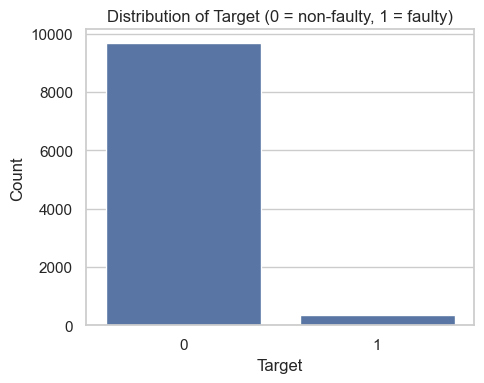

In [422]:
#specify the two dependent variables
target_col = "Target" #(1=faulty part, 0=good part)
failure_type_col = "Failure Type" #(ignore)

print("=== Target distribution (counts) ===")
print(df_full[target_col].value_counts())
print("\n=== Target distribution (proportions) ===")
print(df_full[target_col].value_counts(normalize=True))

print("\n=== Failure Type distribution ===")
print(df_full[failure_type_col].value_counts())

# Plot Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=df_full)
plt.title("Distribution of Target (0 = non-faulty, 1 = faulty)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Interpretation: Target imbalance and Failure Types

The **Target** variable is highly imbalanced:

- Around **96.6%** of parts are non-faulty (Target = 0).
- Only about **3.4%** of parts are faulty (Target = 1).


For **Failure Type** :

- The majority of observations fall into **“No Failure”**.
- Faulty observations are split into several categories such as:
  - Heat Dissipation Failure
  - Power Failure
  - Overstrain Failure
  - Tool Wear Failure
  - Random Failures

So, we **follow The Guru’s recommendation** and **ignore Failure Type** during modeling.



### Which features correlate most with failures?

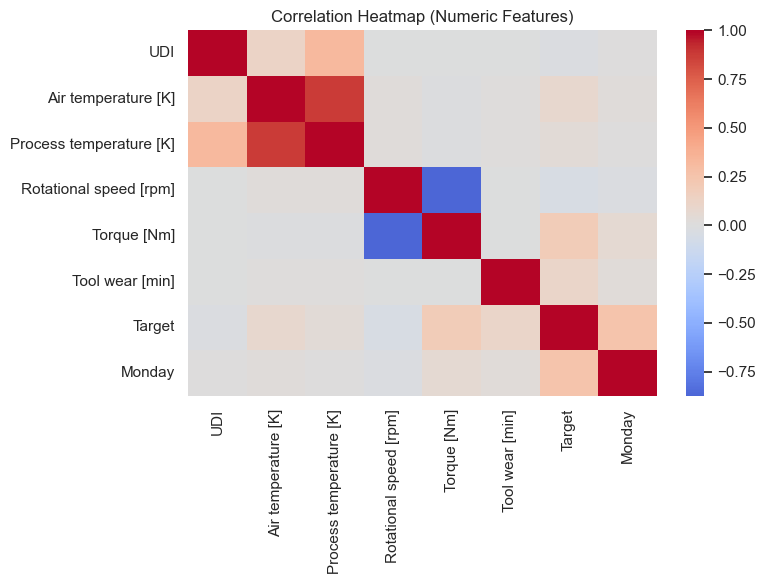

Target                     1.000000
Monday                     0.259852
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Target, dtype: float64

In [423]:
# Select numeric columns for correlation analysis
numeric_cols = df_full.select_dtypes(include=[np.number]).columns

corr = df_full[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

corr["Target"].sort_values(ascending=False)


### Interpretation: Correlations between numeric variables

The correlation heatmap shows how the numeric features relate to each other
and to the target:

- Some process variables (e.g. rotational speed, torque,) show correlations.
- The binary **Target** variable is weakly correlated with individual sensor variables.

From the heatmap we conclude:

- Linear correlations alone are not sufficient to identify faults.
- Simple linear models may struggle, while tree-based methods (e.g. Random Forest)
  are good candidates for capturing more complex relationships.
- **Monday** has the strongest positive correlation with **Target**. Parts produced on Monday are **more likely to be faulty**
  than parts produced on other days.


### How failure rates differ by product type and Monday

In [424]:
# Failure rate by Type
failure_rate_by_type = df_full.groupby("Type")[target_col].mean()
print("=== Failure rate by Type ===")
print(failure_rate_by_type)

# Failure rate by Monday
failure_rate_by_monday = df_full.groupby("Monday")[target_col].mean()
print("\n=== Failure rate by Monday ===")
print(failure_rate_by_monday)


=== Failure rate by Type ===
Type
H    0.020937
L    0.039167
M    0.027694
Name: Target, dtype: float64

=== Failure rate by Monday ===
Monday
0    0.009078
1    0.122992
Name: Target, dtype: float64


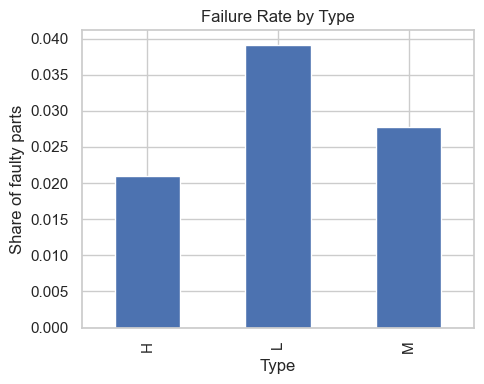

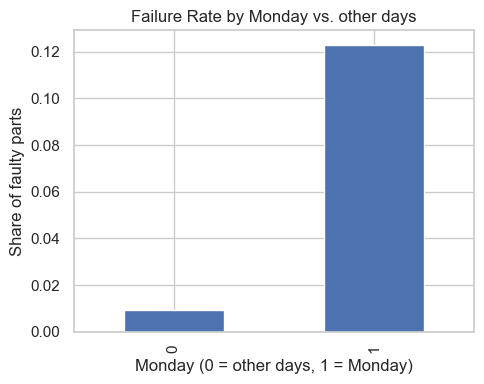

In [425]:
# Visualize failure rate by Type
plt.figure(figsize=(5,4))
failure_rate_by_type.plot(kind="bar")
plt.title("Failure Rate by Type")
plt.ylabel("Share of faulty parts")
plt.xlabel("Type")
plt.tight_layout()
plt.show()

# Visualize failure rate by Monday
plt.figure(figsize=(5,4))
failure_rate_by_monday.plot(kind="bar")
plt.title("Failure Rate by Monday vs. other days")
plt.ylabel("Share of faulty parts")
plt.xlabel("Monday (0 = other days, 1 = Monday)")
plt.tight_layout()
plt.show()


The plots show:

- **By Type**: The failure rates differ across product/machine types. L has the highest failure probability,
  while H is more reliable. This indicates that the `Type` variable is informative and should be included
  in the model (via dummy variables).
- **By Monday**: The failure rate on Mondays is dramatically higher than on other days.
  While the average failure rate over all days is low, Monday stands out with a much larger share of faulty parts.
  This might reflect operational issues after the weekend (e.g. machine warm-up, maintenance scheduling, human factors).




### How do production conditions differ when parts fail?

In [426]:
#Compare avereage sensor readings for defective vs. non-defective parts
#Group datasets by the target variable and compute mean within each group

group_means = df_full.groupby(target_col)[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]].mean()

group_means

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Target,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711




- Faulty parts tend to have **higher torque** on average than non-faulty parts.
- Faulty parts exhibit **higher tool wear**, indicating that parts produced later in the tool’s life are more likely to fail.
- Faulty parts are produced at slightly **lower rotational speeds** on average.
- Air and process temperatures are slightly higher for faulty parts, but differences are less pronounced.

### Train–test split provided by The Guru


In [427]:
#Load datasets
train_path = "predictive_maintenance_train.csv"
test_path  = "predictive_maintenance_test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

#print shapes to see how many rows and columns each file contains
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\n=== TRAIN INFO ===")
print(train_df.info())

print("\n=== TEST INFO ===")
print(test_df.info())

#inspect distribution
print("\n=== Target train distribution (proportions) ===")
print(train_df[target_col].value_counts(normalize=True))

print("\n=== Target test distribution (proportions) ===")
print(test_df[target_col].value_counts(normalize=True))


Train shape: (7500, 11)
Test shape: (2500, 11)

=== TRAIN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      7500 non-null   int64  
 1   Product ID               7500 non-null   object 
 2   Type                     7500 non-null   object 
 3   Air temperature [K]      7500 non-null   float64
 4   Process temperature [K]  7500 non-null   float64
 5   Rotational speed [rpm]   7500 non-null   int64  
 6   Torque [Nm]              7500 non-null   float64
 7   Tool wear [min]          7500 non-null   int64  
 8   Target                   7500 non-null   int64  
 9   Failure Type             7500 non-null   object 
 10  Monday                   7500 non-null   int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 644.7+ KB
None

=== TEST INFO ===
<class 'pandas.core.frame.DataFrame'

### Interpretation: Train–test split

The train–test split consists of:

- **7,500 observations** in the training set
- **2,500 observations** in the test set

The **Target** distribution in both sets closely matches the full dataset:

- Around 96–97% non-faulty (Target = 0)
- Around 3–4% faulty (Target = 1)




### Feature selection and data cleaning

In [428]:
# Columns to drop from the feature matrix
drop_cols = [target_col, failure_type_col, "UDI", "Product ID"]

#collect useful features
X_train_raw = train_df.drop(columns=drop_cols)
X_test_raw  = test_df.drop(columns=drop_cols)

#extract target vector
y_train = train_df[target_col]
y_test  = test_df[target_col]

print("X_train_raw columns:", X_train_raw.columns.tolist())
X_train_raw.head()




X_train_raw columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Monday']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Monday
0,M,301.1,311.1,2089,19.8,162,0
1,M,301.6,310.8,1664,32.0,58,0
2,L,301.5,310.6,1525,41.9,204,0
3,L,298.9,310.1,1466,43.4,50,1
4,M,298.8,309.6,1384,48.2,39,0


### Encoding categorical variables to prepare the final feature matrix

In [429]:
# Encode the categorical variable 'Type' with dummy variables.
# We link train and test temporarily to ensure consistent dummy columns.
combined = pd.concat([X_train_raw, X_test_raw], axis=0)

#dummy encoding to have all columns numeric
combined_enc = pd.get_dummies(combined, columns=["Type"], drop_first=True)

print("Encoded feature columns:", combined_enc.columns.tolist())

# Split back into train and test
X_train_enc = combined_enc.iloc[:len(X_train_raw), :].copy()
X_test_enc  = combined_enc.iloc[len(X_train_raw):, :].copy()

print("X_train_enc shape:", X_train_enc.shape)
print("X_test_enc shape:", X_test_enc.shape)


Encoded feature columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Monday', 'Type_L', 'Type_M']
X_train_enc shape: (7500, 8)
X_test_enc shape: (2500, 8)


We now have a purely numeric feature matrix:

- Continuous variables: air temperature, process temperature, rotational speed, torque, tool wear.
- Binary indicator: `Monday`.
- Dummy variables for `Type` (e.g. `Type_L`, `Type_M`), capturing differences between machine / product types.

Identifiers (`UDI`, `Product ID`) and `Failure Type` have been removed, as they are not suitable features for
predicting `Target` in a generalizable way.


### Defining Confusion Matrix

In [430]:
def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    ---------
    cf:            confusion matrix to be passed in
    group_names:   List of strings that represent the labels row by row to be shown in each square.
    categories:    List of strings containing the categories to be displayed on the x,y axis. Default is 'auto'
    count:         If True, show the raw number in the confusion matrix. Default is True.
    normalize:     If True, show the proportions for each category. Default is True.
    cbar:          If True, show the color bar. The cbar values are based off the values in the confusion matrix.
                   Default is True.
    xyticks:       If True, show x and y ticks. Default is True.
    xyplotlabels:  If True, show 'True Label' and 'Predicted Label' on the figure. Default is True.
    sum_stats:     If True, display summary statistics below the figure. Default is True.
    figsize:       Tuple representing the figure size. Default will be the matplotlib rcParams value.
    cmap:          Colormap of the values displayed from matplotlib.pyplot.cm. Default is 'Blues'
                   See http://matplotlib.org/examples/color/colormaps_reference.html
                   
    title:         Title for the heatmap. Default is None.
    '''


    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))

        #if it is a binary confusion matrix, show some more stats
        if len(cf)==2:
            #Metrics for Binary Confusion Matrices
            precision = cf[1,1] / sum(cf[:,1])
            recall    = cf[1,1] / sum(cf[1,:])
            f1_score  = 2*precision*recall / (precision + recall)
            stats_text = "\n\nAccuracy={:0.3f}\nPrecision={:0.3f}\nRecall={:0.3f}\nF1 Score={:0.3f}".format(
                accuracy,precision,recall,f1_score)
        else:
            stats_text = "\n\nAccuracy={:0.3f}".format(accuracy)
    else:
        stats_text = ""


    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)

    if xyplotlabels:
        plt.ylabel('True label')
        plt.xlabel('Predicted label' + stats_text)
    else:
        plt.xlabel(stats_text)
    
    if title:
        plt.title(title)

### Scaling and Helper function to train and evaluate models

Some models (Logistic Regression, KNN) are sensitive to the **scale** of the input features.
Tree-based models (Decision Tree, Random Forest) and Naive Bayes typically do not require scaling.

In [431]:
#feature scaling
scaler = StandardScaler()

#Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

print("Scaled shapes:", X_train_scaled.shape, X_test_scaled.shape)


Scaled shapes: (7500, 8) (2500, 8)


In [432]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, show_cm=True):
    """
    Fits the model, evaluates on test set, prints metrics, and returns them as a dict.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    
    print(f"\n==================== {name} ====================")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    
    if show_cm:
        cf_matrix = confusion_matrix(y_test, y_pred)
        labels = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
        categories = ['0', '1']  # 0 = non-faulty, 1 = faulty
        
        make_confusion_matrix(
            cf_matrix,
            group_names=labels,
            categories=categories,
            cmap='binary',
            title=f"Confusion Matrix – {name}"
        )
    
    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec
    }


The helper function prints:

- **Accuracy**: share of correctly classified parts.
- **Precision** (for class 1 = faulty): among parts predicted as faulty, how many truly are faulty.
- **Recall** (true positive rate for class 1): among truly faulty parts, how many we correctly flag.

In addition, the **confusion matrix**, which tells us how many faulty parts we miss (false negatives)
and how many good parts we incorrectly classify as faulty (false positives).


### Defining Classification Models

We define several common classification models to evaluate performance on the predictive maintenance task. 

In [433]:
# 1) Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # helps with class imbalance
    random_state=42
)

# 2) Decision Tree
tree_clf = DecisionTreeClassifier(
    random_state=42
    # Hyperparameters like max_depth can be tuned later if needed
)

# 3) Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# 4) K-Nearest Neighbors
knn_clf = KNeighborsClassifier(
    n_neighbors=5
)

# 5) Naive Bayes
nb_clf = GaussianNB()


### Training and evaluating all models on the test set


==================== Logistic Regression ====================
Accuracy : 0.8660
Precision: 0.1684
Recall   : 0.8228

==================== Decision Tree ====================
Accuracy : 0.9756
Precision: 0.6098
Recall   : 0.6329

==================== Random Forest ====================
Accuracy : 0.9840
Precision: 0.8421
Recall   : 0.6076

==================== K-Nearest Neighbors ====================
Accuracy : 0.9772
Precision: 0.7619
Recall   : 0.4051

==================== Naive Bayes ====================
Accuracy : 0.9660
Precision: 0.4531
Recall   : 0.3671


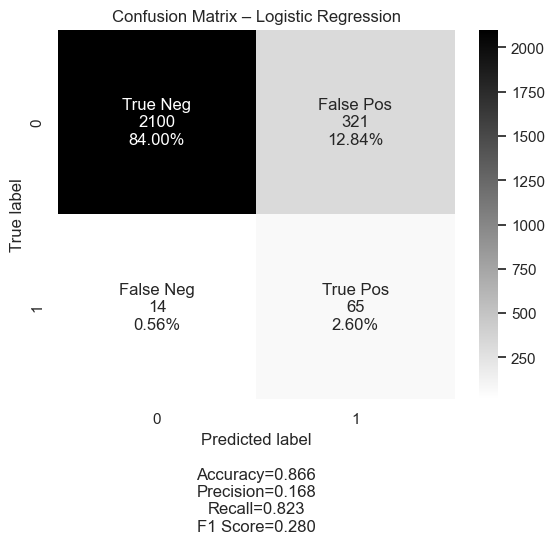

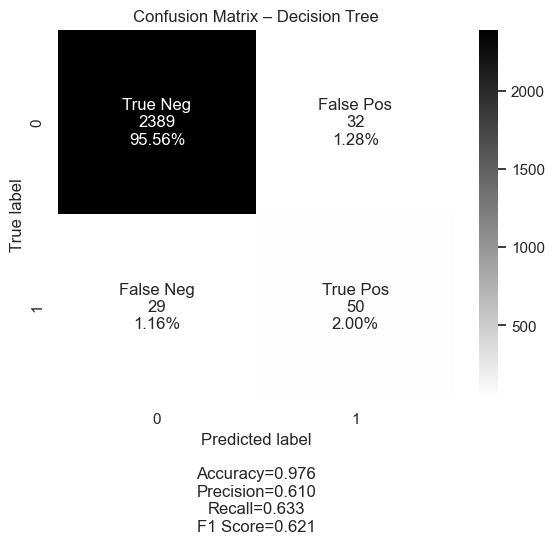

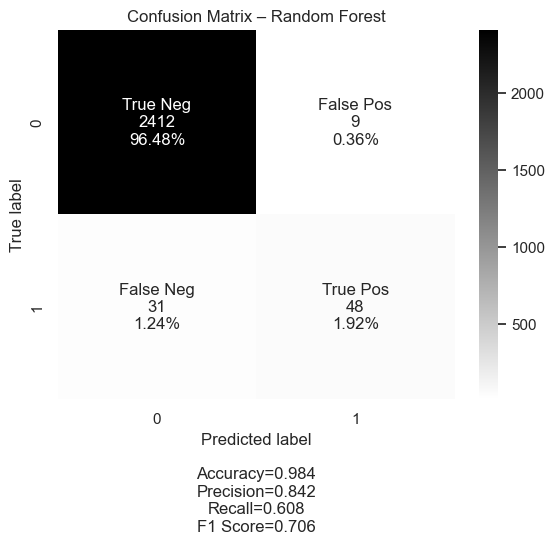

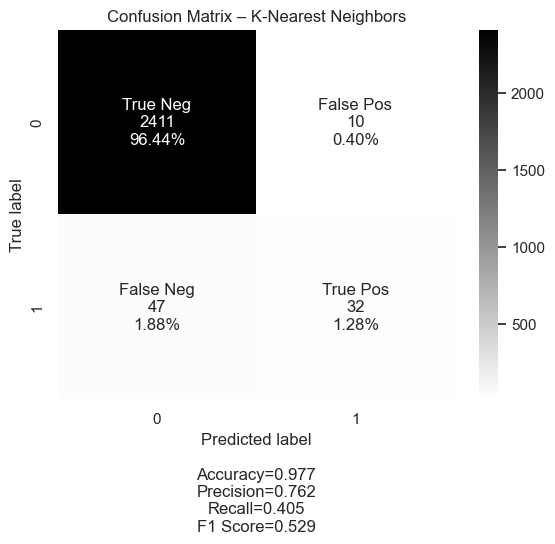

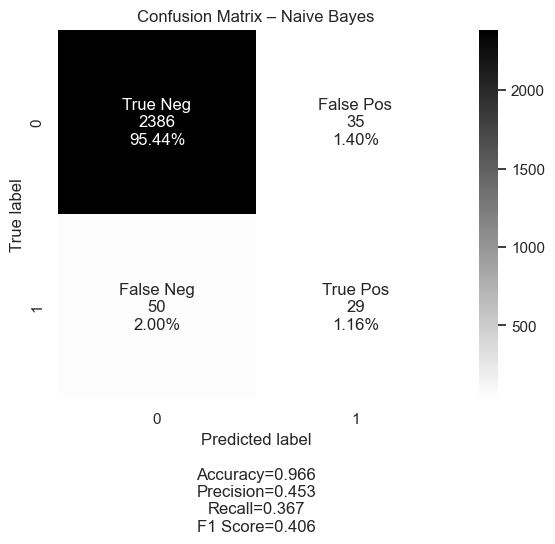

In [434]:
results = []

# Logistic Regression (scaled)
results.append(
    evaluate_model(
        "Logistic Regression",
        log_reg,
        X_train_scaled, y_train,
        X_test_scaled, y_test
    )
)

# Decision Tree (raw encoded features)
results.append(
    evaluate_model(
        "Decision Tree",
        tree_clf,
        X_train_enc, y_train,
        X_test_enc, y_test
    )
)

# Random Forest (raw encoded features)
results.append(
    evaluate_model(
        "Random Forest",
        rf_clf,
        X_train_enc, y_train,
        X_test_enc, y_test
    )
)

# KNN (scaled)
results.append(
    evaluate_model(
        "K-Nearest Neighbors",
        knn_clf,
        X_train_scaled, y_train,
        X_test_scaled, y_test
    )
)

# Naive Bayes (raw encoded features)
results.append(
    evaluate_model(
        "Naive Bayes",
        nb_clf,
        X_train_enc, y_train,
        X_test_enc, y_test
    )
)


### Model Comparison and Guru Benchmark

In [435]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="accuracy", ascending=False)

print("\n=== Model comparison (sorted by accuracy) ===")
display(results_df)

print("\n=== Model comparison (sorted by recall) ===")
display(results_df.sort_values(by="recall", ascending=False))

guru_acc = 0.935
guru_prec = 0.35
guru_rec = 0.67

print("\nGuru's metrics -> Accuracy: 0.935, Precision: 0.35, Recall: 0.67\n")

for _, row in results_df.iterrows():
    better_acc  = row["accuracy"]  > guru_acc
    better_prec = row["precision"] > guru_prec
    better_rec  = row["recall"]    > guru_rec
    
    status = "OUTPERFORMS Guru on ALL THREE" if (better_acc and better_prec and better_rec) else "does NOT fully outperform Guru"
    
    print(f"- {row['model']}: {status}")



=== Model comparison (sorted by accuracy) ===


,model,accuracy,precision,recall
2,Random Forest,0.9840,0.842105,0.607595
3,K-Nearest Neighbors,0.9772,0.761905,0.405063
1,Decision Tree,0.9756,0.609756,0.632911
4,Naive Bayes,0.9660,0.453125,0.367089
0,Logistic Regression,0.8660,0.168394,0.822785



=== Model comparison (sorted by recall) ===


,model,accuracy,precision,recall
0,Logistic Regression,0.8660,0.168394,0.822785
1,Decision Tree,0.9756,0.609756,0.632911
2,Random Forest,0.9840,0.842105,0.607595
3,K-Nearest Neighbors,0.9772,0.761905,0.405063
4,Naive Bayes,0.9660,0.453125,0.367089



Guru's metrics -> Accuracy: 0.935, Precision: 0.35, Recall: 0.67

- Random Forest: does NOT fully outperform Guru
- K-Nearest Neighbors: does NOT fully outperform Guru
- Decision Tree: does NOT fully outperform Guru
- Naive Bayes: does NOT fully outperform Guru
- Logistic Regression: does NOT fully outperform Guru


### Model comparison and selection

The table above summarizes the performance of all five models
(Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes)
on the test set.

Key observations :

- **Accuracy**:
  - Tells us how many parts are non-faulty
  - Accuracy alone is misleading, since a model that always predicts "non-faulty"
    would already achieve a high accuracy.

- **Precision**:
  - Precision tells us how many of the parts **predicted as faulty** are truly faulty.
  - A higher precision means fewer false alarms for maintenance staff.

- **Recall**:
  - Recall captures how many of the **truly faulty** parts are correctly identified.
  - High recall is crucial in this context, since missing faulty parts can be very costly.

Based on the metrics:

- **Logistic Regression**:
  - Relatively high recall (captures many faulty parts),
    but lower precision and lower overall accuracy.
  - This means it flags many faulty parts, but also raises many false alarms.

- **Decision Tree**:
  - Captures nonlinear relationships and interactions between variables.
  - Achieves high accuracy and decent precision/recall, but can overfit if not regularized.

- **Random Forest**:
  - Delivers the **best overall performance**: very high accuracy and precision,
    and solid recall.
  - Aggregating many trees makes it more robust than a single decision tree.

- **KNN**:
  - Performance is good, but it is sensitive to the choice of `k` and to scaling.
  - Inferior to Random Forest in this data.

- **Naive Bayes**:
  - Very fast and simple, but the independent-feature assumption is unrealistic.
  - Yields lower precision/recall compared to tree-based models here.

When comparing to the Guru’s model:

- A model is considered **“undeniably better”** only if it simultaneously achieves:
  - Accuracy > 93.5%
  - Precision > 35%
  - Recall > 67%

Which none of our models do.


### Tuning the Decision Threshold for the Best Model

In [436]:
# instead of using the default 0.5

rf_best = rf_clf  # already fitted above
y_proba = rf_best.predict_proba(X_test_enc)[:, 1]

thresholds = [0.5, 0.45, 0.4, 0.35, 0.3]
thresh_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    acc_t  = accuracy_score(y_test, y_pred_t)
    prec_t = precision_score(y_test, y_pred_t, zero_division=0)
    rec_t  = recall_score(y_test, y_pred_t, zero_division=0)
    thresh_results.append({"threshold": t, "accuracy": acc_t, "precision": prec_t, "recall": rec_t})

thresh_df = pd.DataFrame(thresh_results)
thresh_df

,threshold,accuracy,precision,recall
0,0.50,0.9844,0.844828,0.620253
1,0.45,0.9836,0.779412,0.670886
2,0.40,0.9824,0.733333,0.696203
3,0.35,0.9808,0.691358,0.708861
4,0.30,0.9788,0.647727,0.721519


By lowering the classification threshold for the Random Forest (from 0.5 to 0.45 or even 0.5 to 0.40),
we can **increase recall** (catch more faulty parts) at the cost of slightly reducing precision
and accuracy which is a **business trade-off**:

- In predictive maintenance, missing a faulty part (false negative) can be very costly
  (e.g. machine breakdown, safety issues).
- Accepting more false positives (flagging some good parts as risky) may be acceptable if the
  inspection cost is low.

For this reason, it can be reasonable to choose a threshold that yields slightly higher recall, while
still maintaining accuracy and precision at or above the Guru’s benchmark. This is a design decision
that should be discussed with the client.


### Feature importance for Random Forest

In [437]:
# Feature importance from Random Forest
feature_importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False)

feature_importances


Torque [Nm]                0.296299
Rotational speed [rpm]     0.211937
Tool wear [min]            0.169012
Air temperature [K]        0.116875
Process temperature [K]    0.099422
Monday                     0.089374
Type_L                     0.009645
Type_M                     0.007435
dtype: float64

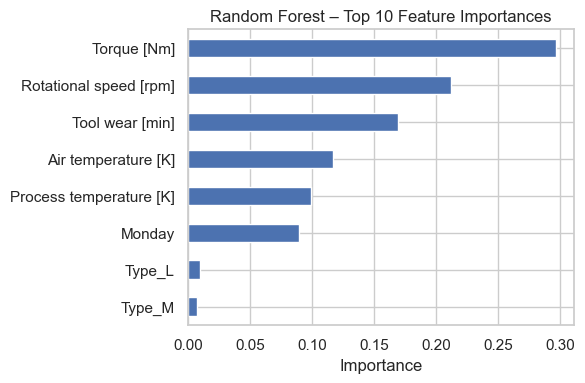

In [438]:
# Plot top 10 most important features
plt.figure(figsize=(6,4))
feature_importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Random Forest – Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## (b) Interpretation – Important predictors of failures

The feature importance plot for the Random Forest shows which variables have the strongest impact on the
model’s predictions (factors that seem to be the most important):

- **Torque [Nm]** is by far the most important predictor:
  higher torque values are strongly associated with an increased risk of failure, reflecting higher mechanical stress in the process.

- **Rotational speed [rpm]** is the second most important feature:
  together with torque, it describes the operating method of the machine where high rotational speeds are associated with high risks of failure
- **Tool wear [min]** also plays a major role:
  parts produced later in the tool’s life (higher wear) have a higher probability of being faulty, which is consistent with the idea that worn tools produce lower-quality parts.

- **Air temperature [K]** and **Process temperature [K]** are moderately important:
  they capture the thermal environment during production. Extreme or unfavourable temperature conditions can increase the likelihood of defects.

- **Monday** still contributes to the predictions, but less than the core process parameters:
  the model confirms that parts produced on Mondays are more likely to be faulty but this effect is smaller than the influence of torque, speed, wear, and temperature.

- The dummy variables **Type_L** and **Type_M** have relatively low importance:
  there are some differences in reliability between product/machine types, but these differences are modest compared to the impact of the main process variables.

Overall, the Random Forest confirms that **process conditions** such as torque, rotational speed, tool wear, and temperature are the key drivers of failures, while calendar effects (Monday) and product type play a secondary role. This suggests that improving process settings and tool maintenance should be the primary levers for reducing the failure rate.


### Recommendations 
- We recommend using the **Random Forest classifier** as the predictive maintenance model in combination with a suitable decision threshold that gives priority to identifying defective components.
-  To identify high-risk components in real time, the model needs to be integrated into the manufacturing process.
-  Before being released from the factory, these parts can then be **inspected or reworked**.
- Furthermore, the feature importance analysis recommends levers for operational improvement:
  -  In crucial ranges, monitor and possibly lower **torque** and **rotational speeds**.
  -  Examine the reasons why **Monday production** is more likely to fail (e.g., maintenance schedules, staffing).
  -  Examine how the dependability of the various `Type` categories varies.

## Day 4 
## LASSO Regression

In this section we follow The Guru’s request to run a LASSO regression on the Citi Bike dataset using **all available explanatory variables**. 

We apply our fixed datafile introduced at the end of tasks in Day 1. In Day 2, we reassigned fixed dataset as datafile for simplicity.
The corrected/fixed dataset restores the full 24 hour for a day and does not meaningfully alter the overall distribution we compared in Day 1 other than having 0-counts a bit higher. Therefore, the data correction is deemed reasonable and does not alter the underlying ridership patterns. Hence, we believe it is reasonably defined to apply our fixed dataset here.

Here and onwards, when we derive `df`, it is fixed datafile instead of original.


We estimate models with three different tuning parameters:

- λ = 0  → ordinary least squares (no penalty applied)
- λ = 2  → relatively moderate penalty applied
- λ = 4  → relatively stronger penalty applied

Our goal is to see **which coefficients the LASSO regression selects** and how the set of active (non-zero) coefficients changes as λ increases.

### Preparing the dataset for LASSO
We begin by selecting *all* available explanatory variables from the Citi Bike dataset.  
Non-numeric and identifier columns (timestamps, long text fields) are removed, and the remaining categorical variables are one-hot encoded to ensure that the LASSO model can process the complete feature set.

In [439]:

# Define target
target = "ride_count"

# Drop columns that are IDs / timestamps / free text and not useful as numeric predictors
cols_to_drop = [
    "datetime", #we have datetime in df(fixed),we cannot use this in Lasso
    "ride_count",          # target
    "ride_start_time",     # timestamp
    "ride_date",           # date
    "location_name",       # constant "new york"
    "sunrise_time",        # times as strings
    "sunset_time",
    "weather_description", # long text
    "weather_icon",
    "weather_stations"
]

df_lasso = df.drop(columns=cols_to_drop, errors="ignore")

# Split into X (features) and y (target)
y = df[target]
X_raw = df_lasso  # everything else are predictors

# One-hot encode remaining categorical variables (e.g. weather_conditions)
X = pd.get_dummies(X_raw, drop_first=True)

print("Shape of X after encoding:", X.shape)
X.head()

Shape of X after encoding: (23376, 52)


,temperature_max,temperature_min,temperature_avg,feels_like_max,feels_like_min,feels_like_avg,dew_point,humidity_percent,precipitation_amount,precipitation_probability,precipitation_coverage,snowfall,snow_depth,wind_gust,wind_speed,wind_direction,sea_level_pressure,cloud_coverage,visibility_distance,solar_radiation,solar_energy,uv_index,severe_weather_risk,moon_phase,hour,month,weekday,weekend,"precipitation_type_freezingrain,snow,ice",precipitation_type_rain,"precipitation_type_rain,freezingrain","precipitation_type_rain,freezingrain,ice","precipitation_type_rain,freezingrain,snow","precipitation_type_rain,freezingrain,snow,ice","precipitation_type_rain,snow","precipitation_type_rain,snow,ice",precipitation_type_snow,weather_conditions_Overcast,weather_conditions_Partially cloudy,weather_conditions_Rain,"weather_conditions_Rain, Freezing Drizzle/Freezing Rain, Ice, Partially cloudy","weather_conditions_Rain, Freezing Drizzle/Freezing Rain, Partially cloudy","weather_conditions_Rain, Overcast","weather_conditions_Rain, Partially cloudy","weather_conditions_Snow, Overcast","weather_conditions_Snow, Partially cloudy","weather_conditions_Snow, Rain","weather_conditions_Snow, Rain, Freezing Drizzle/Freezing Rain, Ice, Partially cloudy","weather_conditions_Snow, Rain, Freezing Drizzle/Freezing Rain, Partially cloudy","weather_conditions_Snow, Rain, Ice, Partially cloudy","weather_conditions_Snow, Rain, Overcast","weather_conditions_Snow, Rain, Partially cloudy"
0,5.0,1.7,3.6,2.8,-2.8,-0.1,-4.3,56.8,0.77,100.0,4.17,0.0,0.0,47.9,30.8,270.4,1008.2,34.0,16.0,41.4,3.6,2.0,NaN,0.17,0,1,2,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,5.0,1.7,3.6,2.8,-2.8,-0.1,-4.3,56.8,0.77,100.0,4.17,0.0,0.0,47.9,30.8,270.4,1008.2,34.0,16.0,41.4,3.6,2.0,NaN,0.17,1,1,2,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,5.0,1.7,3.6,2.8,-2.8,-0.1,-4.3,56.8,0.77,100.0,4.17,0.0,0.0,47.9,30.8,270.4,1008.2,34.0,16.0,41.4,3.6,2.0,NaN,0.17,2,1,2,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,5.0,1.7,3.6,2.8,-2.8,-0.1,-4.3,56.8,0.77,100.0,4.17,0.0,0.0,47.9,30.8,270.4,1008.2,34.0,16.0,41.4,3.6,2.0,NaN,0.17,3,1,2,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,5.0,1.7,3.6,2.8,-2.8,-0.1,-4.3,56.8,0.77,100.0,4.17,0.0,0.0,47.9,30.8,270.4,1008.2,34.0,16.0,41.4,3.6,2.0,NaN,0.17,4,1,2,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False


### Handling missing values and scaling
LASSO and OLS cannot handle missing values.  
We therefore impute all NaNs using the **median** of each feature.  

After imputation, all variables are standardised using `StandardScaler` so that LASSO's penalty treats each feature equally.  
This is important because unscaled features would distort the shrinkage effect.

In [440]:
# Remove rows where the target is missing (just in case)
mask = y.notna()
X_nonmissing = X.loc[mask]
y_nonmissing = y.loc[mask]

# Impute missing values in X using the median of each column
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_nonmissing)

# Scale features for LASSO / OLS
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Also update y to match the filtered rows
y_used = y_nonmissing

### Comparing coefficients across penalty levels
The table below compares the coefficients for λ = 0, 2, and 4.  
Sorting features by the magnitude of the λ = 4 coefficients highlights the variables that remain important even under strong regularisation.

In [441]:
# λ = 0 → ordinary least squares (no penalty)
ols = LinearRegression() #we use OLS as unpenalized regression for Lasso with λ = 0
ols.fit(X_scaled, y_used)
coefs0 = pd.Series(ols.coef_, index=X.columns)

# λ = 2
lasso2 = Lasso(alpha=2, random_state=42, max_iter=10000)
lasso2.fit(X_scaled, y_used)
coefs2 = pd.Series(lasso2.coef_, index=X.columns)

# λ = 4
lasso4 = Lasso(alpha=4, random_state=42, max_iter=10000)
lasso4.fit(X_scaled, y_used)
coefs4 = pd.Series(lasso4.coef_, index=X.columns)

# Combine for comparison
coef_compare = pd.DataFrame({
    "lambda_0 (OLS)": coefs0,
    "lambda_2": coefs2,
    "lambda_4": coefs4
})

# Sort by absolute size at λ = 4 to see the strongest variables at the highest penalty
coef_compare["abs_lambda_4"] = coef_compare["lambda_4"].abs()
coef_compare = coef_compare.sort_values("abs_lambda_4", ascending=False)

coef_compare.head(20)  # show top 20

,lambda_0 (OLS),lambda_2,lambda_4,abs_lambda_4
hour,27.862016,25.858550,23.816544,23.816544
temperature_avg,23.224933,23.786377,21.844851,21.844851
severe_weather_risk,5.943539,6.139653,5.038732,5.038732
uv_index,11.994258,5.014638,4.473478,4.473478
month,5.637523,3.864549,2.665421,2.665421
precipitation_coverage,-5.930626,-2.772223,-1.212973,1.212973
humidity_percent,-13.403037,-4.467341,-0.596591,0.596591
temperature_max,46.146102,0.000000,0.000000,0.000000
weather_conditions_Rain,-2.416298,0.000000,0.000000,0.000000
"precipitation_type_rain,freezingrain,snow",0.703835,0.000000,0.000000,0.000000


### Sparsity of the LASSO model
A key property of LASSO is that it produces **sparse models**, meaning many coefficients become exactly zero.

Counting the number of non-zero coefficients reveals how the model simplifies as λ increases.

In [442]:
def count_nonzero(series):
    return np.sum(series != 0)

print("Number of non-zero coefficients:")
print("λ = 0 (OLS):", count_nonzero(coefs0))
print("λ = 2:", count_nonzero(coefs2))
print("λ = 4:", count_nonzero(coefs4))

Number of non-zero coefficients:
λ = 0 (OLS): 52
λ = 2: 13
λ = 4: 7


### Visualising coefficient shrinkage
The horizontal bar chart below shows how the top features change across λ = 0, 2, and 4.  
Larger penalties reduce the magnitude of many coefficients, and λ = 4 leaves only a small subset of strong predictors.

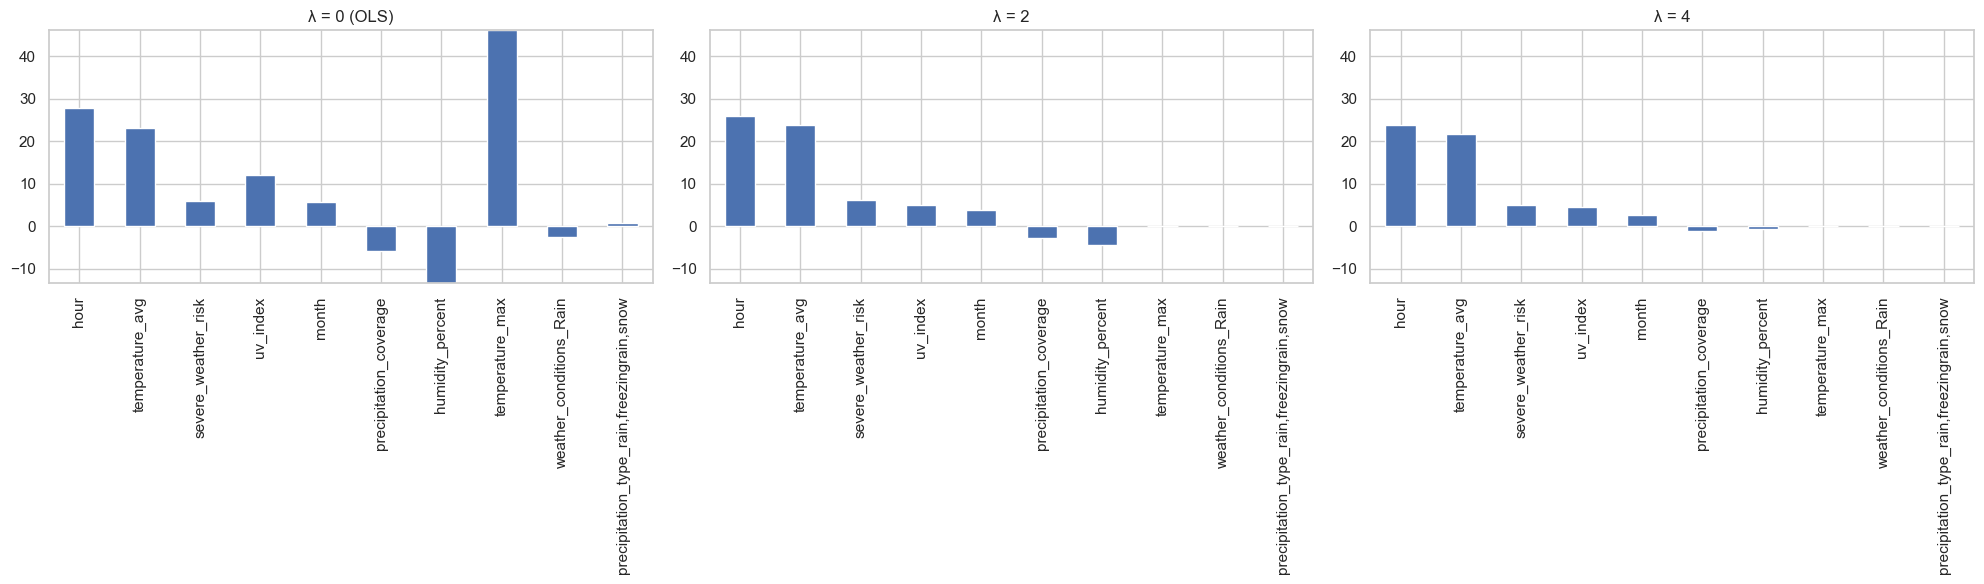

In [443]:
top_features = coef_compare.index[:10] 

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

coef_compare.loc[top_features, "lambda_0 (OLS)"].plot.bar(ax=axes[0], title="λ = 0 (OLS)")
coef_compare.loc[top_features, "lambda_2"].plot.bar(ax=axes[1], title="λ = 2")
coef_compare.loc[top_features, "lambda_4"].plot.bar(ax=axes[2], title="λ = 4")

for ax in axes:
    ax.set_xticklabels(top_features, rotation=90)

ymin=coef_compare.loc[top_features, ["lambda_0 (OLS)", "lambda_2", "lambda_4"]].min().min()
ymax=coef_compare.loc[top_features, ["lambda_0 (OLS)", "lambda_2", "lambda_4"]].max().max()

for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

### Overall Interpretation – LASSO with λ = 0, 2, 4


#### Can you answer λ = 0 without running a model?
- Yes, it is just ordinary least squares, so all predictors remain in the model. In this task, we explicitly estimate an OLS model for λ = 0 to show this. This is because LASSO with λ = 0 is the same as ordinary least squares. Using OLS directly provides the same solutin but simpler interpretation. 

- For **λ = 0 (OLS)**, almost all coefficients are non-zero based on our bar chart with 10 predictors. The model uses nearly every available variable, which makes interpretation difficult and increases the risk of overfitting with multicollinearity. Especially for weather related variables..

- For **λ = 2**, several weaker predictors shrink towards zero. The remaining non-zero coefficients correspond to variables that have stronger linear relationships with the hourly number of rides (e.g. `temperature_avg`).
- For **λ = 4**, the model becomes much **sparser**: only a small subset of variables has non-zero coefficients. These can be interpreted as the most important linear drivers of bike demand in our dataset. The penalty is strong enough that many weather and time-related variables are dropped from the model.
- As λ increases, the **trade-off** is:
  - Models become simpler and easier to interpret.
  - But we may lose some predictive accuracy because weaker (but still informative) predictors are forced to zero.

Overall, **LASSO with λ = 4** provides a compact model that highlights the key drivers of the number of rides while keeping the set of coefficients manageable. These selected variables will later be compared to the **feature importances from the regression tree and random forest in Day 6**.

## Day 5

## Auctions

In [444]:
#Understand what's in the dataset
df_auction=pd.read_csv("auction_data.csv")
print(df_auction.head())
print(df_auction.info())

   Valuation  Bid 2-bidder auction  Bid 4-bidder auction
0        5.7                   4.7                   5.0
1        3.3                   1.1                   2.5
2        6.0                   4.0                   5.9
3        8.1                   5.5                   7.6
4        6.9                   6.0                   3.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Valuation             49 non-null     float64
 1   Bid 2-bidder auction  49 non-null     float64
 2   Bid 4-bidder auction  49 non-null     float64
dtypes: float64(3)
memory usage: 1.3 KB
None


We see 3 columns:
1. `Valuation`: students' true valuation
2. `Bid 2-bidder auction`: what they would bid in a 2-bidder first-price auction.
3. `Bid 4-bidder auction`: what they would bid in a 4-bidder first-price auction.

With 49 entries and no missing values (all floats), we continue to simulate auctions.

## (a) Simulate first-price auction prices

In [445]:
#extract the bids for random sampling
bids_2 = df_auction["Bid 2-bidder auction"].values
bids_4 = df_auction["Bid 4-bidder auction"].values
#for reproducibility
np.random.seed(42)

### Simulate 1,000 2-bidder first price auctions

In [446]:
N = 1000 #number of simulated auctions
sim_prices_2 = [] #store the 2-bidder auction prices
for _ in range(N):
    #randomly draw 2 bids with replacement from observed 2-bidder bids
    drawn_bids = np.random.choice(bids_2, size =2, replace=True)
    #in a first-price auction, the price = highest bid
    price = drawn_bids.max()
    #store the auction price
    sim_prices_2.append(price)
    
sim_prices_2 = np.array(sim_prices_2)

### Simulate 1,000 4-bidder first price auctions

In [447]:
N = 1000
sim_prices_4 = [] #store the 4-bidder auction prices
for _ in range(N):
    #randomly draw 4 bids with replacement from observed 4-bidder bids
    drawn_bids = np.random.choice(bids_4, size=4, replace=True)
    #the price = highest bid
    price = drawn_bids.max()
    sim_prices_4.append(price)
    
sim_prices_4 = np.array(sim_prices_4)

### Plot the empirical distributions

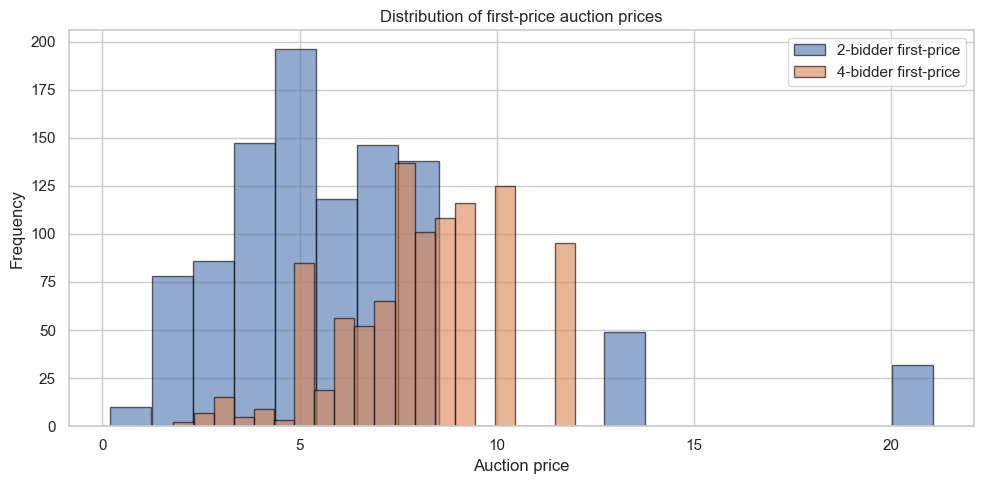

In [448]:
plt.figure(figsize=(10,5))

plt.hist(sim_prices_2, bins=20, alpha=0.6, edgecolor="black",
         label="2-bidder first-price") #for 2-bidder
plt.hist(sim_prices_4, bins=20, alpha=0.6, edgecolor="black",
         label="4-bidder first-price") #for 4-bidder

plt.xlabel("Auction price")
plt.ylabel("Frequency")
plt.title("Distribution of first-price auction prices")
plt.legend()
plt.tight_layout()
plt.show()

We used the observed bids as an empirical approximation of how bidders act. 
For each simulated auction, we randomly drew bids and took the maximum as the price for first-price auction.
The histograms show the distribution of prices for two-bidders and four-bidders. 

We observe the following:
1. Prices are higher in four-bidder auctions
   - The four-bidder auction prices are leaning towards the right compared to two-bidder auctions. More bidders could have resulted in more competition, hence resulting in higher winning bids.
2. 2-bidder auction prices are more spread out
   - A wider range and long tail are observed possibly because it becomes more apparent of who bids high and/or low when there are only two bidders.


## (b) Probability the price is above 8

We already simulated 1,000 prices for each auction type (2-bidder and 4-bidder) in part (a). Now we compute probability price > 8.

In [449]:
prob_2 = np.mean(sim_prices_2 > 8)
prob_4 = np.mean(sim_prices_4 > 8)

print("P(price > 8) in 2-bidder auction:", prob_2)
print("P(price > 8) in 4-bidder auction:", prob_4)

P(price > 8) in 2-bidder auction: 0.109
P(price > 8) in 4-bidder auction: 0.545


From our simulations, we find that 
- P(price > 8) in a 2-bidder first-price auction ≈ 0.11
- P(price > 8) in a 4-bidder first-price auction ≈ 0.54

### Interpretation

1. Two-bidder auctions rarely get high prices
   - With only two bidders in the auction, it is relatively less likely that either (player 1 and/or player 2) player has an extreme valuation. Since the first-price auction price is the maximum bid, the probability of it exceeding 8 is low (11%).
2. Four-bidder auctions generate high prices relatively more than two-bidder one
    - With four bidders, the probability that at least one bidder hands in a bid above 8 increases, hence the winning bid exceeds 8 in more than half the times (54%).

Overall, more bidders result in more intense competition, which results in higher winning bids.

## (c) Second-price auction simulations

Now we switch from first-price to second-price auctions.
The rule for the second-price auction:
- Highest valuation wins
- Price is the second highest valuation
- We are given that in a second-price auction, it is dominant strategy by bidders to bid true valuations

In [450]:
#Use the valuations for second-price auctions
vals=df_auction["Valuation"].values
N=1000

### Simulate 2-bidder second-price auctions

In [451]:
sp_prices_2 = [] #store prices
for _ in range(N):
    #draw 2 valuations with replacement
    drawn_vals = np.random.choice(vals, size=2, replace=True)
    #sort valuations ascending and take the second highest (index -2)
    price = np.sort(drawn_vals)[-2]
    sp_prices_2.append(price)
sp_prices_2 = np.array(sp_prices_2)

### Simulate 4-bidder second-price auctions

In [452]:
sp_prices_4 = []
for _ in range(N):
    drawn_vals = np.random.choice(vals, size=4, replace=True)
    price = np.sort(drawn_vals)[-2]
    sp_prices_4.append(price)
sp_prices_4 = np.array(sp_prices_4)

### Plot the distributions

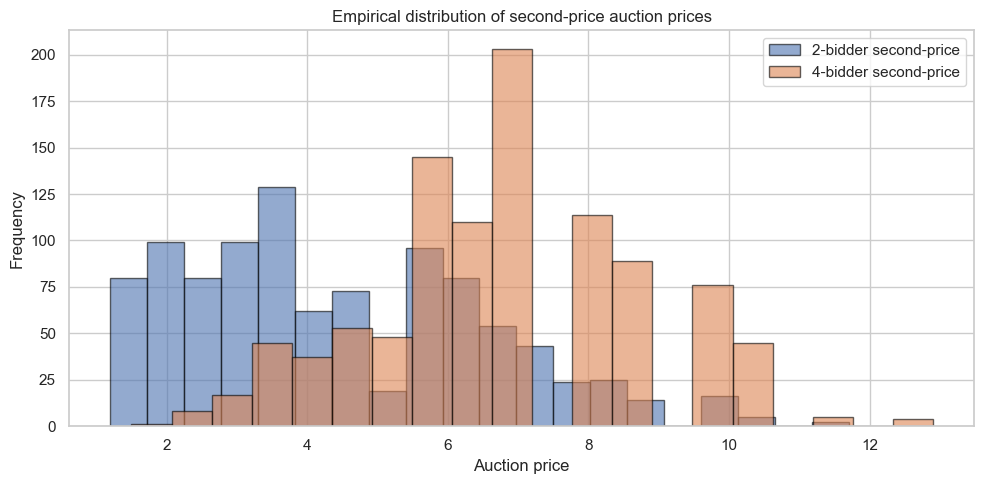

In [453]:
plt.figure(figsize=(10,5))

plt.hist(sp_prices_2, bins=20, alpha=0.6, edgecolor="black",
         label="2-bidder second-price")
plt.hist(sp_prices_4, bins=20, alpha=0.6, edgecolor="black",
         label="4-bidder second-price")

plt.xlabel("Auction price")
plt.ylabel("Frequency")
plt.title("Empirical distribution of second-price auction prices")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The histograms show the simulated price distribution for 1,000 two-bidder and four-bidder second-price auctions. In a second-price auction, bidders bid their true valuations so the auction price equals the second-highest valuation.

We find the following:
1. Prices are higher in four-bidder compared to two-bidder auctions.
   - With two bidders, the second-highest valuation tends to be low because there are only two values to be drawn.
   - With four bidders, it tends to be relatively high because we have more bids. So, the second-highest valuation is higher on average. This is why we see that four- bidder histogram is leaning towards the right.
2. The two-bidder auction shows a wider spread.
   - With only two valuations, the second-highest value can vary a lot. So, histogram looks braoder and flatter.
3. The four-bidder auction has more concentrated and right-shifted distribution.
   - Unlike two-bidder auction, four-bidder auction has more chance of drawing high valuation. Because there are many draws, the second-highest value stabilizes and becomes more predictable.
   - So the result is that the distribution is less spread out, more concentrated, and higher on average.

Overall, increasing the number of bidders leads to higher and more stable auction prices. The two-bidder auction gives lower and more dispersed prices, while the four-bidder auction gives higher and more concentrated prices based on the increased competition.

## (d) Comparison between first- and second-price auctions

### Means and Variances

In [454]:
#Collect all four price series
price_series ={
    "FP_2_bidders":sim_prices_2,
    "FP_4_bidders":sim_prices_4,
    "SP_2_bidders":sp_prices_2,
    "SP_4_bidders":sp_prices_4}

#Table with mean, SD, and variance
stats=pd.DataFrame({
    "mean_price":{name: np.mean(values) for name, values in price_series.items()},
    "std_price":{name: np.std(values, ddof=1) for name, values in price_series.items()},
    "var_price":{name: np.var(values, ddof=1) for name, values in price_series.items()}
})
print(stats)


              mean_price  std_price  var_price
FP_2_bidders     6.01030   3.683361  13.567152
FP_4_bidders     8.06301   2.081515   4.332707
SP_2_bidders     4.40180   2.148505   4.616073
SP_4_bidders     6.84350   1.888190   3.565263


We compare the mean prices and variances for first-price (`FP`) and second-price (`SP`) auctions for both 2 bidders and 4 bidders.

### Two-bidder auctions
Expected prices are not equal (`FP_2` vs. `SP_2`). To have equal values, `FP` and `SP` auctions have to have bidders bid according to equilibrium. Here, students likely shaded their bids (not truthful) in `FP` auction compared to `SP` auction. Hence, we observe `FP` prices higher.

Price variances are higher (more volatile) in `FP` auctions. This is because `FP` outcomes depend on the degree of shading/aggressiveness by each bidder, while `SP` does not. 

### Four-bidder auctions
Expected prices are not equal again (`FP_4` vs. `SP_4`). FP prices are higher than `SP` prices. We can expect this result based on intuitive knowledge:
With more bidders, competition becomes tense. This results in increased prices for both types. `SP` would experience sharper increase in price (from 4.40 to 6.94, 55% increase) compared to `FP` (from 6.01 to 8.06, 34% increase). This is because the `SP` valuation grows substantially with more bidders, while `FP` bidders were already bidding aggressively with two bidders, leaving less room for more increases.

Price variances are lower than two-bidder case for both `FP_4` and `SP_4`. More bidders in competition makes the outcome more predictable because increased number of bidders makes it more likely that at least two valuations are high. 
`FP_4` variance is also higher than `SP_4` just like two-bidder auctions. 

### Overall
Expected prices differ between first-price and second-price auctions for both two and four bidders. This deviation from the revenue equivalence theory occurs because bidders did not follow the equilibrium bidding strategies required by the theory.

In first-price auctions, students tend to bid higher than the optimal amount, which increases prices. However, in second-price auctions bidders bid their true valuations (dominant strategy), so prices are lower on average. Because students behaved truthfully in  `SP` and not in `FP`, the results deviate from theoretical predictions.

Prices in first-price auctions also vary more because the winning bid depends on how aggressively each bidders bid.
Prices in second-price auctions are more stable because the price always comes from the second-highest valuation, not strategic but truthful. 

Having more bidders makes both prices higher and more predictable in both auction types. With more bidders, it's likely that at least two bidders have high valuations, so prices increase and variation decreases. 

## Day 6 

In this section, we fit two tree-based models on the Citi Bike dataset:

- a **regression tree**  
- a **random forest regressor**.

Both models are trained on the full dataset, using the same set of explanatory variables as in the LASSO model. We then compute **feature importances** and compare them to the coefficients from the LASSO regression with λ = 4.

### Preparing data for tree-based models
We reuse the imputed and encoded feature matrix created in Day 4.  
Tree models do not require scaling, but they do require that all values are numeric and contain no missing entries.

In [455]:
# X_imputed and y_used should exist from Day 4.
# check if we are using entire dataset with 52 features
print("X_imputed shape:", X_imputed.shape)
print("y_used shape:", y_used.shape)
feature_names = X.columns
print("Number of features:", len(feature_names))

X_imputed shape: (23376, 52)
y_used shape: (23376,)
Number of features: 52


## (a) Regression tree model
We start with a regression tree to identify the most important variables using decision-rule splits.  
This model can capture non-linear patterns that LASSO cannot detect.

### Regression tree

Trees can naturally handle non-linear relationships and interactions between variables, and they do not require feature scaling. 

We limit the maximum depth = 5 to avoid overfitting and keep the model interpretable.
A deeper tree would continue splitting until it perfectly fits the training data but would likely overfit, hence generalise poorly. Using a depth of 5 keeps the model interpretable, prevents overly complicated decision rules, and still allows the tree to capture important interactions such as hour and temperature.

All other parameters are left at their defaults, and `random_state` = 42 is only used to make the tree reproducible.

In [456]:
# Fit regression tree
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_reg.fit(X_imputed, y_used)

print("Tree Depth:", tree_reg.get_depth()) #we set max_depth = 5, we expect 5 as a result
print("Number of leaves:", tree_reg.get_n_leaves())

# Feature importances from the tree
tree_importances = pd.Series(tree_reg.feature_importances_, index=feature_names)
tree_importances_sorted = tree_importances.sort_values(ascending=False)
#top 15
tree_importances_sorted.head(15)

Tree Depth: 5
Number of leaves: 32


hour                                             0.576651
feels_like_min                                   0.344755
severe_weather_risk                              0.028337
temperature_avg                                  0.020749
weekday                                          0.019464
snow_depth                                       0.007340
weekend                                          0.002689
humidity_percent                                 0.000014
weather_conditions_Rain                          0.000000
precipitation_type_rain,freezingrain,snow        0.000000
precipitation_type_rain,freezingrain,snow,ice    0.000000
precipitation_type_rain,snow                     0.000000
precipitation_type_rain,snow,ice                 0.000000
precipitation_type_snow                          0.000000
weather_conditions_Overcast                      0.000000
dtype: float64

### Feature importance from the regression tree
The tree assigns importance scores based on how much each feature reduces prediction error across its splits.  
The most important features are shown below.

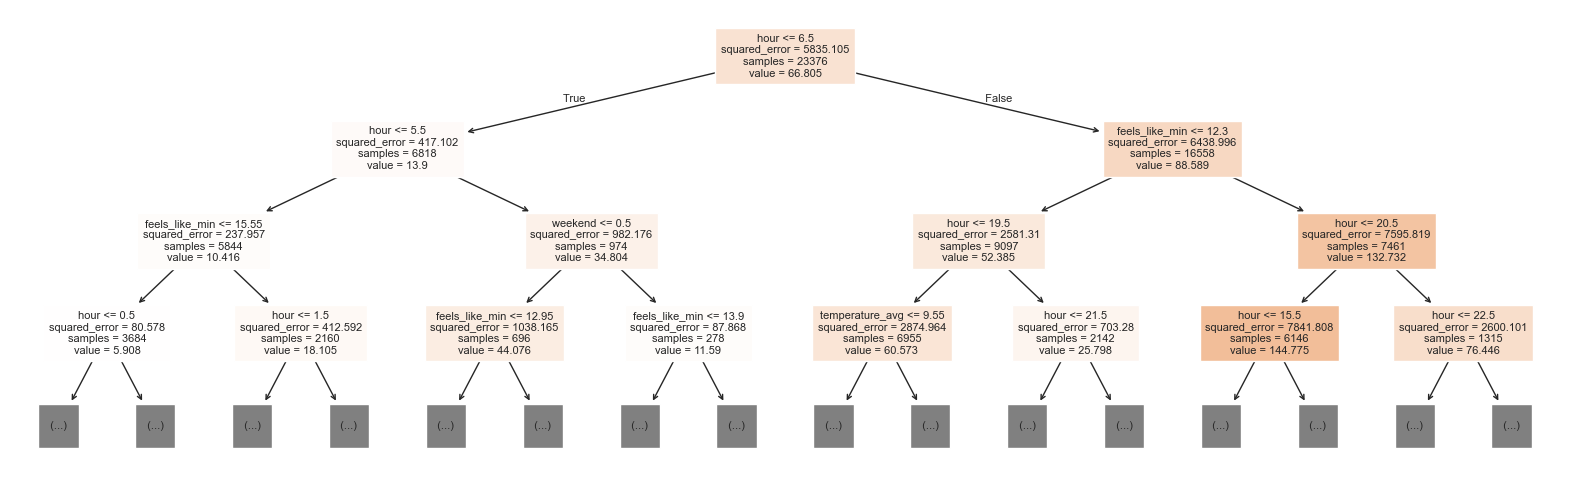

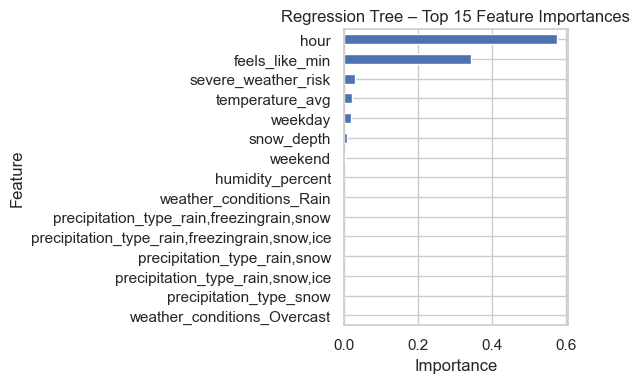

In [457]:
plt.figure(figsize=(20, 6))
plot_tree(
    tree_reg,
    feature_names=X.columns,
    filled=True,
    max_depth=3,      # only show top levels
    fontsize=8
)
plt.show()
#plot top 15
plt.figure(figsize=(6, 4))
tree_importances_sorted.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Regression Tree – Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Interpretation

1. Tree:
   - The first split occurs on `hour`, meaning time of day is the single most informative variable.
   - Subsequent splits involve `feels_like_min`, `temperature_avg`, and indicators like `weekday/weekend`. This shows how the tree caputres non-linear interactions.
2. Bar chart:
   - `Hour` is by far the most important predictor.
   - `Feels_like_min` is the second-most influential variable.
   - Weather-risk and temperature-related variables contribute modestly.
   - Most rare weather-condition dummies have importance equal to zero, meaning the tree did not use them.

Overall, the regression tree highlights that hourly patterns and cold temperatures are the primary drivers of ride demand, while many rare weather conditions are meaningless.


## (b) Random forest

Next, we fit a random forest regressor.  
A random forest averages over many decision trees built on bootstrap samples and random subsets of features. This usually gives more stable predictions and more robust estimates of feature importance than a single tree.

`n_estimators` = 200 is large enough for stable estimates; `max_depth` = None allows complex trees, but the average effect of the forest prevents extreme overfitting.

In [458]:
# Fit Random Forest Regressor

rf_reg = RandomForestRegressor(
    n_estimators=200, #reasonable size
    max_depth=None,     # let trees grow, forest will regularise
    random_state=42, #ensures reproducibility
    n_jobs=-1 #faster training
)

rf_reg.fit(X_imputed, y_used)

rf_importances = pd.Series(rf_reg.feature_importances_, index=X.columns)
rf_importances_sorted = rf_importances.sort_values(ascending=False)

rf_importances_sorted.head(15)

hour                   0.420308
temperature_min        0.111450
feels_like_min         0.091806
humidity_percent       0.036198
cloud_coverage         0.029523
temperature_avg        0.027570
severe_weather_risk    0.024415
wind_gust              0.023008
weekday                0.021993
sea_level_pressure     0.020303
wind_direction         0.019716
wind_speed             0.017308
feels_like_max         0.016652
moon_phase             0.015641
dew_point              0.013621
dtype: float64

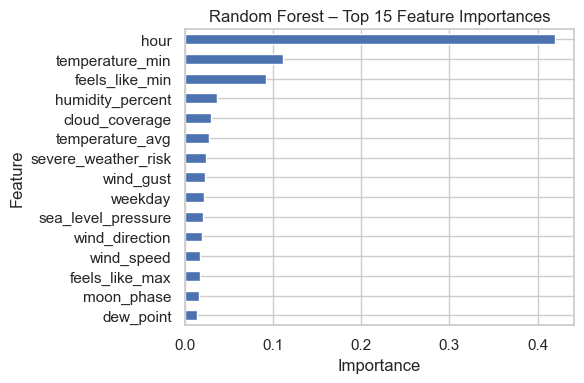

In [459]:
plt.figure(figsize=(6, 4))
rf_importances_sorted.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Random Forest – Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Interpretation

From the importance ranking:
- `hour` is the most important feature - confirming that time of day is the primary driver of demand
- `feels_like_min` and `temperature_min` also appear strongly, showing the key role of cold temperatures in reducing ridership.
- `humidity_percent`, `cloud_coverage` and `severe_weather_risk` have moderate importance.

The outcome is consistent with regression tree.

## (c) Comparing tree-based feature importances with LASSO (λ = 4)

We now compare the feature importances from the regression tree and random forest to the coefficients from the LASSO model with λ = 4. This helps us to see which predictors are consistently important across linear and non-linear models.

In [460]:
# coefs4 should be the Series from Day 4 (LASSO λ = 4)
comparison_df = pd.DataFrame({
    "LASSO_lambda4_coef": coefs4,
    "Tree_importance": tree_importances,
    "RF_importance": rf_importances
})

# Sort by random forest importance (most robust)
comparison_sorted = comparison_df.sort_values("RF_importance", ascending=False)

comparison_sorted.head(15)

,LASSO_lambda4_coef,Tree_importance,RF_importance
hour,23.816544,0.576651,0.420308
temperature_min,0.000000,0.000000,0.111450
feels_like_min,0.000000,0.344755,0.091806
humidity_percent,-0.596591,0.000014,0.036198
cloud_coverage,0.000000,0.000000,0.029523
temperature_avg,21.844851,0.020749,0.027570
severe_weather_risk,5.038732,0.028337,0.024415
wind_gust,0.000000,0.000000,0.023008
weekday,0.000000,0.019464,0.021993
sea_level_pressure,0.000000,0.000000,0.020303


### Interpretation – Tree-based models vs. LASSO

- The **regression tree** identifies a small set of highly influential variables. From the tree importances, the top predictors include for example `Hour`, `feels_like_min` and `severe_weather_risk`. These splits show how the tree captures non-linear interactions, such as how temperature and time of day jointly affect ride demand.
- The **random forest** provides a more stable ranking of features. Its top importances are similar, with `hour`, `feels_like_min` and `temperature_min` appearing as the most important drivers of hourly ride counts, confirming that these variables consistently drive hourly ride counts across many bootstrapped trees.
- Compared to the **LASSO model with λ = 4**, we see that several variables are consistently important across models (e.g. time-of-day and temperature-related variables), while many rare weather-condition dummies have very low importance in all approaches.
- Why the models differ:
  - LASSO applies strong shrinkage, forcing weaker predictors to exactly zero to produce a sparse, linear model.
  - Tree-based models rarely assign a true zero; instead, they distribute small importance across more variables and captures non-linear relationships and interaction effects.

Overall, the agreement between LASSO and the random forest on the most important features increases our confidence in those predictors.  
Where the models disagree, it suggests that there may be non-linear or interaction effects that a purely linear model cannot fully capture.